# Generating manuscript figures and tables

Figure and table generation for the manuscript.
FIGURES
  Fig 2        – 5 selected montages × 3 models × 3 metrics (F1, sensitivity, FA/hr)
                 Stripplot / violin with bootstrapped mean ± 95 CI overlay
  Fig 2 ver2   – Same data, mean ± CI only; unique marker per model, color per montage, no dots
  Fig 3        – Patient-wise stratified heatmap (epilepsy type, laterality, location)
                 Saved twice: once for Sensitivity, once for F1 Score
  Supp Fig A   – Seizure-level stratified heatmap (seizure laterality, seizure location)
                 NaN / unknown location values are excluded before Temporal/Extra-temporal split
  Supp Fig B   – All-montage heatmap sorted by overall F1 performance

  All figures are saved as both .png (300 dpi) and .svg for downstream vector editing.

TABLES (CSV + styled Excel)
  Supp Table 2/3/4 – One per model; rows = montages (Supp Table 1 order),
                     cols = AUROC, AUPRC, Sensitivity, FA/hr, F1 (mean ± SD and mean [95 CI])
                     AUROC/AUPRC columns are resolved via common alternative column name aliases
                     (roc_auc, auc_roc, pr_auc, auc_pr, etc.) in case the upstream pipeline
                     writes them under a different name.

Usage
-----
python manuscript_plots_v2.py \\
    --results_dir /path/to/results_root \\
    --patient_info /path/to/emu_patient_info.csv \\
    --seizure_data /path/to/emu_seizure_details.csv \\
    [--setting_folder thres_optimal] \\
    [--output_dir figures_v2]

Expected directory layout (mirrors manuscript_plots2.py):
  results_root/
    metrics_timescoring/
      <setting_folder>/
        <montage_name>/
          patient_metrics.csv   # one row per patient; cols include f1_event, recall_event, fp,
                                #   and auroc/auprc (or aliases: roc_auc, pr_auc, auc_roc, etc.)
          segment_metrics.csv   # one row per seizure event, col recall_event
"""


### Imports and Functions

In [5]:
import argparse
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import ptitprince as pt
import pickle
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.utils import resample


warnings.filterwarnings("ignore")

# ── Helpers ───────────────────────────────────────────────────────────────────

def save_figure(out_dir, basename):
    """
    Save the current matplotlib figure as both PNG (300 dpi) and SVG
    so that figures can be further edited in vector graphics tools.

    Parameters
    ----------
    out_dir  : str   Output directory (must already exist).
    basename : str   Filename *without* extension, e.g. 'Figure2_MultiModel_strip'.

    Returns
    -------
    png_path : str   Path to the saved PNG file.
    """
    png_path = os.path.join(out_dir, f"{basename}.png")
    svg_path = os.path.join(out_dir, f"{basename}.svg")
    plt.savefig(png_path, bbox_inches="tight", dpi=300)
    plt.savefig(svg_path, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {png_path}")
    print(f"  Saved: {svg_path}")
    return png_path


# # ── Style ────────────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-ticks")
sns.set_context("paper", font_scale=1.6)
plt.rcParams.update({"font.family": "sans-serif", "figure.dpi": 300})

# ── Constants ─────────────────────────────────────────────────────────────────
# Keys match montage_dict exactly.

# Canonical montage order (mirrors Supp Table 1)
SUPP_TABLE1_ORDER = [
    "full",                       # Full 16-channel bipolar
    "epiminder_2",                # C3-P3, C4-P4   (Epiminder simulated via interpolation)
    "uneeg_diag_left_front",      # F3-T3
    "uneeg_diag_right_front",     # F4-T4
    "uneeg_diag_bilateral_front", # F3-T3, F4-T4
    "uneeg_left_front",           # F7-T3
    "uneeg_right_front",          # F8-T4
    "uneeg_bilateral_front2",     # F7-T3, F8-T4
    "uneeg_vert_left",            # C3-T3
    "uneeg_vert_right",           # C4-T4
    "uneeg_vert_bilateral",       # C3-T3, C4-T4
    "uneeg_diag_left_back",       # P3-T3
    "uneeg_diag_right_back",      # P4-T4
    "uneeg_diag_bilateral_back",  # P3-T3, P4-T4
    "uneeg_left_back",            # T3-T5
    "uneeg_right_back",           # T4-T6
    "uneeg_bilateral_back2",      # T3-T5, T4-T6
    "ceribell"
]

# Human-readable labels — channel-pair names only
MONTAGE_LABELS = {
    "full":                       "Full",
    "epiminder_2":                "C3-P3, C4-P4",
    "uneeg_diag_left_front":      "F3-T3",
    "uneeg_diag_right_front":     "F4-T4",
    "uneeg_diag_bilateral_front": "F3-T3, F4-T4",
    "uneeg_left_front":           "F7-T3",
    "uneeg_right_front":          "F8-T4",
    "uneeg_bilateral_front2":     "F7-T3, F8-T4",
    "uneeg_vert_left":            "C3-T3",
    "uneeg_vert_right":           "C4-T4",
    "uneeg_vert_bilateral":       "C3-T3, C4-T4",
    "uneeg_diag_left_back":       "P3-T3",
    "uneeg_diag_right_back":      "P4-T4",
    "uneeg_diag_bilateral_back":  "P3-T3, P4-T4",
    "uneeg_left_back":            "T3-T5",
    "uneeg_right_back":           "T4-T6",
    "uneeg_bilateral_back2":      "T3-T5, T4-T6",
    "ceribell":                   "Circumferential",
}

# Group labels used for table row coloring and legend annotations
MONTAGE_GROUPS = {
    "full":                       "Full",
    "epiminder_2":                "Centro-parietal",
    "uneeg_diag_left_front":      "Fronto-temporal",
    "uneeg_diag_right_front":     "Fronto-temporal",
    "uneeg_diag_bilateral_front": "Fronto-temporal",
    "uneeg_left_front":           "Fronto-temporal",
    "uneeg_right_front":          "Fronto-temporal",
    "uneeg_bilateral_front2":     "Fronto-temporal",
    "uneeg_vert_left":            "Centro-temporal",
    "uneeg_vert_right":           "Centro-temporal",
    "uneeg_vert_bilateral":       "Centro-temporal",
    "uneeg_diag_left_back":       "Temporo-parietal",
    "uneeg_diag_right_back":      "Temporo-parietal",
    "uneeg_diag_bilateral_back":  "Temporo-parietal",
    "uneeg_left_back":            "Posterior temporal",
    "uneeg_right_back":           "Posterior temporal",
    "uneeg_bilateral_back2":      "Posterior temporal",
    "ceribell":                   "Circumferential",
}

# Selected montages for main figures (Fig 2, Fig 3)
SELECTED_MONTAGES = [
    "full",
    "uneeg_diag_bilateral_front",
    "uneeg_diag_left_front",
    "uneeg_diag_right_front",
    "epiminder_2",
]

FULL_MONTAGES = list(MONTAGE_LABELS.keys())

colors = ["#cecece","#082a54", "#e02b35", "#F47C6D", "#368899"]
MONTAGE_PALETTE = {k:v for k,v in zip(SELECTED_MONTAGES, colors)}

patient_info = "/mnt/sauce/littlab/users/haoershi/emu_dataset/dataset_admission_info.csv"
seizure_data = "/mnt/sauce/littlab/users/haoershi/emu_dataset/ueoeec_seizure_details.csv"

# ── Data Loading ──────────────────────────────────────────────────────────────

def load_all_metrics(results_dir, setting_folder):
    """Load patient_metrics.csv and segment_metrics.csv for every montage × model subfolder."""
    base = os.path.join(results_dir, "metrics_timescoring", setting_folder)
    if not os.path.exists(base):
        base = os.path.join(results_dir, "metrics", setting_folder)
        if not os.path.exists(base):
            print(f"[WARN] Path not found: {base}")
            return pd.DataFrame(), pd.DataFrame()

    montages = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
    p_dfs, s_dfs = [], []

    for m in tqdm(montages, desc=f"Loading {setting_folder}"):
        m_path = os.path.join(base, m)

        # --- patient metrics ---
        p_file = os.path.join(m_path, "patient_metrics.csv")
        if os.path.exists(p_file):
            try:
                df = pd.read_csv(p_file)
                if "patient_id" not in df.columns and "Unnamed: 0" in df.columns:
                    df = df.rename(columns={"Unnamed: 0": "patient_id"})
                # Normalise AUROC / AUPRC column names to canonical 'auroc' / 'auprc'.
                # The actual pipeline writes them as 'auroc_sample' / 'auprc_sample';
                # aliases cover any other naming conventions used by upstream code.
                _AUROC_ALIASES = ["auroc_sample", "roc_auc", "auc_roc", "auc",
                                  "AUROC", "auroc_score"]
                _AUPRC_ALIASES = ["auprc_sample", "pr_auc", "auc_pr", "prauc",
                                  "AUPRC", "auprc_score", "average_precision"]
                if "auroc" not in df.columns:
                    for alias in _AUROC_ALIASES:
                        if alias in df.columns:
                            df = df.rename(columns={alias: "auroc"})
                            break
                if "auprc" not in df.columns:
                    for alias in _AUPRC_ALIASES:
                        if alias in df.columns:
                            df = df.rename(columns={alias: "auprc"})
                            break
                df["montage"] = m
                p_dfs.append(df)
            except Exception as e:
                print(f"  Error {p_file}: {e}")

        # --- segment / seizure metrics ---
        s_file = os.path.join(m_path, "segment_metrics.csv")
        if os.path.exists(s_file):
            try:
                df = pd.read_csv(s_file)
                if "Unnamed: 0" in df.columns:
                    df = df.rename(columns={"Unnamed: 0": "event_id"})
                if "recall_event" in df.columns:
                    df["detected_binary"] = (df["recall_event"] > 0).astype(int)
                df["montage"] = m
                s_dfs.append(df)
            except Exception as e:
                print(f"  Error {s_file}: {e}")

    df_p = pd.concat(p_dfs, ignore_index=True) if p_dfs else pd.DataFrame()
    df_s = pd.concat(s_dfs, ignore_index=True) if s_dfs else pd.DataFrame()
    return df_p, df_s


def load_multi_model_metrics(results_dir_map, setting_map):
    """
    Load metrics for multiple models.

    Parameters
    ----------
    results_dir_map : dict  {model_name: results_dir}
    setting_map     : dict  {model_name: setting_folder}

    Returns
    -------
    df_p, df_s  – combined DataFrames with 'model' column
    """
    all_p, all_s = [], []
    for model_name, rdir in results_dir_map.items():
        setting = setting_map.get(model_name, "thres_optimal")
        print(f"\n=== Loading {model_name} from {rdir} / {setting} ===")
        dp, ds = load_all_metrics(rdir, setting)
        if not dp.empty:
            dp["model"] = model_name
            all_p.append(dp)
        if not ds.empty:
            ds["model"] = model_name
            all_s.append(ds)
        if 'admission_id' not in dp.columns:
            dp.columns = ['admission_id'] + list(dp.columns[1:])

    df_p = pd.concat(all_p, ignore_index=True) if all_p else pd.DataFrame()
    df_s = pd.concat(all_s, ignore_index=True) if all_s else pd.DataFrame()
    return df_p, df_s


def load_metadata(patient_info_path, seizure_details_path):
    """
    Load dataset_admission_info.csv and (optionally) seizure details.

    dataset_admission_info.csv columns used:
        admission_id   – primary join key (e.g. EMU0878)
        patient_id     – numeric patient identifier
        laterality     – left / right / bilateral  (Title-cased on load)
        location       – temporal / frontal / multifocal  (Title-cased)
        epilepsy_type  – focal / gen / mixed  ('gen' -> 'Generalized')
    """
    p_info, s_info = pd.DataFrame(), pd.DataFrame()

    if os.path.exists(patient_info_path):
        p_info = pd.read_csv(
            patient_info_path,
            dtype={"admission_id": str, "patient_id": str},
        )
        for col in ["laterality", "location", "epilepsy_type", "gender"]:
            if col in p_info.columns:
                p_info[col] = p_info[col].astype(str).str.strip().str.title()
        # 'Gen' is stored as abbreviation in the CSV
        p_info["epilepsy_type"] = p_info["epilepsy_type"].replace({"Gen": "Generalized"})
        print(f"Loaded patient info: {len(p_info)} admissions from {patient_info_path}")
    else:
        print(f"[WARN] Patient info not found: {patient_info_path}")

    if os.path.exists(seizure_details_path):
        s_info = pd.read_csv(seizure_details_path)
        if "off" in s_info.columns and "ueoeec" in s_info.columns:
            s_info["duration"] = s_info["off"] - s_info["ueoeec"]
        print(f"Loaded seizure details: {len(s_info)} rows from {seizure_details_path}")
    else:
        print(f"[WARN] Seizure details not found: {seizure_details_path}")

    return p_info, s_info

# ── Helpers ───────────────────────────────────────────────────────────────────

def bootstrap_ci(data, n_boot=1000, ci=95, seed=42):
    data = np.asarray(data, dtype=float)
    data = data[~np.isnan(data)]
    if len(data) == 0:
        return np.nan, np.array([[np.nan], [np.nan]])
    if len(data) < 2:
        return float(data[0]), np.array([[0.0], [0.0]])
    rng = np.random.default_rng(seed)
    boot = [rng.choice(data, size=len(data), replace=True).mean() for _ in range(n_boot)]
    mean = np.mean(data)
    lo = np.percentile(boot, (100 - ci) / 2)
    hi = np.percentile(boot, 100 - (100 - ci) / 2)
    return mean, np.array([[mean - lo], [hi - mean]])


def label(m):
    return MONTAGE_LABELS.get(m, m)


def ordered_montages(df, montages_wanted, col="montage"):
    avail = df[col].unique()
    return [m for m in montages_wanted if m in avail]


def _get_models(df, models_wanted, col="model"):
    if "model" in df.columns:
        return [m for m in models_wanted if m in df["model"].unique().tolist()]
    return ["(single model)"]


In [12]:
results_dir = '/mnt/sauce/littlab/users/joekoji/montage-proj'
use_me = True
if use_me:
    model_dirs = ['/mnt/sauce/littlab/users/haoershi/limited_montage/sparcnet_results',
                  '/mnt/sauce/littlab/users/haoershi/limited_montage/dynasd_results', 
                  '/mnt/sauce/littlab/users/haoershi/limited_montage/svm_results'] #,'/mnt/sauce/littlab/users/haoershi/limited_montage/feat_results',
else:
    model_dirs = ['/mnt/sauce/littlab/users/joekoji/montage-proj/sparcnet_results',
                  '/mnt/sauce/littlab/users/joekoji/montage-proj/dynasd_results_fixed', 
                  '/mnt/sauce/littlab/users/joekoji/montage-proj/svm_results']
model_names = ['SPaRCNet', 'NDD', 'SVM']
# ── Resolve data sources ────────────────────────────────────────────────────
results_dir_map = dict(zip(model_names, model_dirs))

In [13]:
# setting_folder = 'thres_optimal_f1'
# settings = [setting_folder] * len(model_names)
settings = ['thres_optimal_f1','thres_optimal_f1_avg','thres_optimal_f1_avg']# ,'thres_optimal_f1'['thres_fixedfar_1','thres_fixedfar_1_avg','thres_optimal_f1_avg']#
setting_map = dict(zip(model_names, settings))
df_p, df_s = load_multi_model_metrics(results_dir_map, setting_map)
# df_s[['precision_event','f1_event']] = df_s[['precision_event','f1_event']].fillna(0.0)
# df_p[['precision_event','f1_event']] = df_p[['precision_event','f1_event']].fillna(0.0)        
if df_p.empty:
    raise SystemExit("No patient metrics loaded. Check your directory structure.")
out_dir = 'manuscript/f1_ver_update'
os.makedirs(out_dir, exist_ok=True)
print(f"\nOutput directory: {out_dir}")
print(f"Patient rows loaded: {len(df_p)}")
print(f"Seizure rows loaded: {len(df_s)}")

# ── Load metadata ───────────────────────────────────────────────────────────
p_info, s_info = load_metadata(patient_info, seizure_data)


=== Loading SPaRCNet from /mnt/sauce/littlab/users/haoershi/limited_montage/sparcnet_results / thres_optimal_f1 ===


Loading thres_optimal_f1: 100%|██████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 107.82it/s]



=== Loading NDD from /mnt/sauce/littlab/users/haoershi/limited_montage/dynasd_results / thres_optimal_f1_avg ===


Loading thres_optimal_f1_avg: 100%|███████████████████████████████████████████████████████| 18/18 [00:00<00:00, 99.10it/s]



=== Loading SVM from /mnt/sauce/littlab/users/haoershi/limited_montage/svm_results / thres_optimal_f1_avg ===


Loading thres_optimal_f1_avg: 100%|██████████████████████████████████████████████████████| 18/18 [00:00<00:00, 103.71it/s]



Output directory: manuscript/f1_ver_update
Patient rows loaded: 25164
Seizure rows loaded: 173340
Loaded patient info: 466 admissions from /mnt/sauce/littlab/users/haoershi/emu_dataset/dataset_admission_info.csv
Loaded seizure details: 1683 rows from /mnt/sauce/littlab/users/haoershi/emu_dataset/ueoeec_seizure_details.csv


In [8]:
def load_full_prob(results_dir_map):
    """
    Load metrics for multiple models.

    Parameters
    ----------
    results_dir_map : dict  {model_name: results_dir}
    setting_map     : dict  {model_name: setting_folder}

    Returns
    -------
    df_p, df_s  – combined DataFrames with 'model' column
    """
    all_data = {}
    for model_name, rdir in results_dir_map.items():
        pred_dir = os.path.join(rdir,'pred',setting_map[model_name])
        print(f"\n=== Loading {model_name} from {pred_dir} ===")
        montages = os.listdir(pred_dir)
        use_montages = [m for m in SELECTED_MONTAGES if m in montages]
        model_data = []
        for m in use_montages:
            prob_files = os.listdir(os.path.join(pred_dir, m))
            for f in tqdm(prob_files):
                tmp = pd.read_csv(os.path.join(pred_dir,m,f))
                tmp = tmp[['sz_prob','label']] if 'sz_prob' in tmp.columns else tmp[['LPD','label']].rename(columns={'LPD':'sz_prob'}) 
                tmp['event_id'] = f[:-4]
                tmp['montage'] = m
                model_data.append(tmp)
        model_data = pd.concat(model_data)
        model_data['patient'] = model_data['event_id'].apply(lambda x: x.split('_')[0])
        all_data[model_name] = model_data
    return all_data

In [9]:
SELECTED_MONTAGES = list(MONTAGE_GROUPS.keys())
prob_data = load_full_prob(results_dir_map)


=== Loading SPaRCNet from /mnt/sauce/littlab/users/haoershi/limited_montage/sparcnet_results/pred/thres_optimal_f1 ===


 44%|███████████████████████████████████▊                                             | 1417/3210 [00:14<00:18, 95.08it/s]


KeyboardInterrupt: 

### Table 1

In [7]:
patient_info = pd.read_csv('../emu_dataset/dataset_patient_info.csv')

In [9]:
patient_info.columns

Index(['patient_id', 'gender', 'laterality', 'location', 'epilepsy_type',
       'diagnosis', 'race1', 'ethnicity', 'marital_status',
       'employment_status', 'occupation', 'smoking_status', 'num_sz_event',
       'num_iic_segment', 'avg_sz_dura'],
      dtype='str')

In [10]:
from tableone import TableOne
table1 = TableOne(patient_info, columns=['gender', 'laterality', 'location', 'epilepsy_type'], categorical=['gender', 'laterality', 'location', 'epilepsy_type'])
table1

Missing     Overall
n                                               436
gender, n (%)        Female              237 (54.4)
                     Male                199 (45.6)
laterality, n (%)    None                120 (27.5)
                     bilateral            58 (13.3)
                     left                156 (35.8)
                     right               102 (23.4)
location, n (%)      None                138 (31.7)
                     frontal               22 (5.0)
                     multifocal            36 (8.3)
                     temporal            240 (55.0)
epilepsy_type, n (%) None                  35 (8.0)
                     focal               331 (75.9)
                     gen                   43 (9.9)
                     mixed                 27 (6.2)

In [12]:
table1 = TableOne(patient_info[patient_info['epilepsy_type'].isin(['focal', 'mixed'])], columns=['gender', 'laterality', 'location', 'epilepsy_type'], categorical=['gender', 'laterality', 'location', 'epilepsy_type'])
table1

Missing     Overall
n                                               358
gender, n (%)        Female              187 (52.2)
                     Male                171 (47.8)
laterality, n (%)    None                 42 (11.7)
                     bilateral            58 (16.2)
                     left                156 (43.6)
                     right               102 (28.5)
location, n (%)      None                 60 (16.8)
                     frontal               22 (6.1)
                     multifocal           36 (10.1)
                     temporal            240 (67.0)
epilepsy_type, n (%) focal               331 (92.5)
                     mixed                 27 (7.5)

### Figure 2

In [21]:
# ── Figure 2 – Stripplot / Violin + Mean CI, 3 metrics × 3 models ────────────
def generate_figure2_multi(df_p, out_dir, style="strip", suffix=''):
    """
    Figure 2: 5 selected montages × 3 models × 3 metrics.
    style = 'strip' (jittered dots) or 'violin'
    """
    models = _get_models(df_p, SELECTED_MODELS)
    montages = ordered_montages(df_p, SELECTED_MONTAGES)
    if not montages:
        print("[WARN] No selected montages found for Fig 2. Skipping.")
        return

    metrics = [
        ("f1_event",     "F1 Score",            (-0.03, 1.03)),
        ("recall_event", "Sensitivity",          (-0.03, 1.03)),
        ("fp",           "False Alarms / Hour",  None),
    ]
    available_metrics = [(c, n, yl) for c, n, yl in metrics if c in df_p.columns]
    if not available_metrics:
        print("[WARN] No metric columns found in patient DataFrame. Skipping Fig 2.")
        return

    n_metrics = len(available_metrics)
    n_models  = len(models)

    fig, axes = plt.subplots(
        n_models, n_metrics,
        figsize=(5 * n_metrics, 4 * n_models+1),
        squeeze=False,
        sharex=True,
        sharey="col",
    )

    for row_i, model in enumerate(models):
        sub = df_p[df_p["model"] == model] if "model" in df_p.columns else df_p

        for col_i, (col, name, ylim) in enumerate(available_metrics):
            ax = axes[row_i][col_i]
            if col not in sub.columns:
                ax.set_visible(False)
                continue

            plot_data = sub[sub["montage"].isin(montages)].copy()
            plot_data["montage_label"] = plot_data["montage"].map(label)
            mont_labels = [label(m) for m in montages]

            if style == "violin":
                sns.violinplot(
                    data=plot_data, x="montage_label", y=col, order=mont_labels,
                    palette={label(m): MONTAGE_PALETTE[m] for m in montages},
                    inner=None, cut=0, linewidth=0.8, alpha=0.6, ax=ax,
                )
            elif style == 'strip':  # strip
                sns.stripplot(
                    data=plot_data, x="montage_label", y=col, order=mont_labels,
                    palette={label(m): MONTAGE_PALETTE[m] for m in montages},
                    jitter=0.2, size=3, alpha=0.3, zorder=1, ax=ax,
                )
        
                sns.pointplot(
                        data=plot_data, x="montage_label", y=col, order=mont_labels,
                        # palette={label(m): mont_color[m] for m in montages},
                        estimator='mean',
                        dodge=False, linestyle="none", errorbar=("ci", 95),
                        marker="_", markersize=25, markeredgewidth=3,zorder=10,errwidth=1,color='black', ax=ax
                    )
            elif style == 'box':
                sns.boxplot(
                        data=plot_data, x="montage_label", y=col, order=mont_labels,
                        palette={label(m): MONTAGE_PALETTE[m] for m in montages},#sns.color_palette("Paired"),#
                        notch=False, showcaps=True,showfliers=False,width=0.5,
                        # boxprops={'edgeco'}
                        medianprops={"color": "black", "linewidth": 2},zorder=0,
                        ax=ax
                    )
                
                for patch in ax.patches:
                    color = patch.get_facecolor()
                    patch.set_facecolor((*color[:3], 0.5)) # transparent
                    # patch.set_edgecolor(color)
                    patch.set_linewidth(1)
                # for i, line in enumerate(ax.lines):
                #     color = ax.patches[i // 6].get_edgecolor()  # each box has ~6 lines
                #     line.set_color(color)
                #     line.set_linewidth(2)

                sns.stripplot(
                    data=plot_data, x="montage_label", y=col, order=mont_labels,
                    palette={label(m): MONTAGE_PALETTE[m] for m in montages},#sns.color_palette("Paired"),#
                    jitter=0.15, size=4, alpha=0.5, zorder=1, ax=ax,
                )
        
                
            elif style == 'raincloud':
                pt.RainCloud(
                    x="montage_label", y=col, data=plot_data, order=mont_labels, hue_order=mont_labels,
                    palette=[MONTAGE_PALETTE[m] for m in montages], #sns.color_palette("viridis"),#
                    bw=0.2, width_viol=0.6, ax=ax, orient="v", alpha=0.8, pointplot=True, move=0.25, offset=0.1, jitter=0.12,
                    box_showfliers=False, rain_alpha=0.5
                )
            if ylim:
                ax.set_ylim(ylim)
            ax.set_title(f"{name}" if row_i == 0 else "", fontweight="bold", pad=8)
            ax.set_ylabel(model if col_i == 0 else "", fontweight="bold")
            ax.set_xlabel("")
            ax.set_xticklabels(mont_labels, rotation=40, ha="right", fontsize=12)
            if col_i ==1:
                ax.set_yticklabels([])
                ax.yaxis.set_tick_params(labelleft=False)
            # ax.yaxis.grid(True, linestyle="--", alpha=0.5)

    plt.suptitle("Seizure Detection Performance – Selected Montages", fontsize=15, y=1.01)
    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"Figure2_MultiModel_{style}{suffix}")


# ── Figure 2 – Stripplot / Violin + Mean CI, 3 metrics × 3 models ────────────

def generate_figure2_f1(df_p, out_dir, style="strip",suffix=''):
    """
    Figure 2: 5 selected montages × 3 models × 3 metrics.
    style = 'strip' (jittered dots) or 'violin'
    """
    models = _get_models(df_p, SELECTED_MODELS)
    montages = ordered_montages(df_p, SELECTED_MONTAGES)
    if not montages:
        print("[WARN] No selected montages found for Fig 2. Skipping.")
        return

    metrics = [
        ("f1_event",     "F1 Score",            (-0.03, 1.03))
    ]
    available_metrics = [(c, n, yl) for c, n, yl in metrics if c in df_p.columns]
    col, name, ylim = available_metrics[0]
    n_metrics = len(available_metrics)
    n_models  = len(models)

    fig, axes = plt.subplots(n_metrics, n_models,
        figsize=(4 * n_models, 5*n_metrics), squeeze=True
    )
    if (n_metrics == 1) & (n_models == 1):
        axes = [axes]

    df_p["montage_label"] = df_p["montage"].map(label)
    mont_labels = [label(m) for m in montages]
    for row_i, model in enumerate(models):
        sub = df_p[df_p["model"] == model] if "model" in df_p.columns else df_p
        sub = sub[sub["montage"].isin(montages)].copy()
        ax = axes[row_i]
        if style == "violin":
            sns.violinplot(
                data=sub, x="montage_label", y=col, order = mont_labels,
                palette={label(m): MONTAGE_PALETTE[m] for m in montages},
                inner=None, cut=0, linewidth=0.8, alpha=0.6, ax=ax,
            )
        elif style == 'strip':  # strip
            sns.stripplot(
                data=sub, x="montage_label", y=col, order = mont_labels,
                palette={label(m): MONTAGE_PALETTE[m] for m in montages}, 
                jitter=0.2, size=3, alpha=0.3, zorder=1, ax=ax,
            )
    
            sns.pointplot(
                    data=sub, x="montage_label", y=col, order = mont_labels,
                    # palette={label(m): mont_color[m] for m in montages},
                    estimator='mean',
                    dodge=False, linestyle="none", errorbar=("ci", 95),
                    marker="_", markersize=25, markeredgewidth=3,zorder=10,errwidth=1,color='black', ax=ax
                )
        elif style == 'box':
            sns.boxplot(
                    data=sub, x="montage_label", y=col, order = mont_labels,
                    palette={label(m): MONTAGE_PALETTE[m] for m in montages},#sns.color_palette("Paired"),#
                    notch=False, showcaps=True,showfliers=False,width=0.5,
                    # boxprops={'edgeco'}
                    medianprops={"color": "black", "linewidth": 2},zorder=0,
                    ax=ax
                )
            
            for patch in ax.patches:
                color = patch.get_facecolor()
                patch.set_facecolor((*color[:3], 0.5)) # transparent
                # patch.set_edgecolor(color)
                patch.set_linewidth(1)
            # for i, line in enumerate(ax.lines):
            #     color = ax.patches[i // 6].get_edgecolor()  # each box has ~6 lines
            #     line.set_color(color)
            #     line.set_linewidth(2)
    
            sns.stripplot(
                data=sub, x="montage_label", y=col, order = mont_labels,
                palette={label(m): MONTAGE_PALETTE[m] for m in montages},#sns.color_palette("Paired"),#
                jitter=0.15, size=4, alpha=0.5, zorder=1, ax=ax,
            )
    
            
        elif style == 'raincloud':
            pt.RainCloud(
                    x="montage_label", y=col, data=sub, order=mont_labels, hue_order=mont_labels,
                    palette=[MONTAGE_PALETTE[m] for m in montages], #sns.color_palette("viridis"),#
                    bw=0.2, width_viol=0.6, ax=ax, orient="v", alpha=0.7, pointplot=True, move=0.25, offset=0.1, jitter=0.12,
                    box_showfliers=False, rain_alpha=0.5
                )
        if ylim:
            ax.set_ylim(ylim)
        ax.set_title(f"{model}", fontweight="bold", pad=8)
        ax.set_ylabel(name if row_i == 0 else "", fontweight="bold")
        ax.set_xlabel("")
        ax.set_xticklabels(mont_labels, rotation=40, ha='right', fontsize=12)
        if row_i != 0:
            ax.set_yticklabels([])
            ax.yaxis.set_tick_params(labelleft=False)
        # ax.yaxis.grid(True, linestyle="--", alpha=0.5)

    plt.suptitle("Seizure Detection Performance – Selected Montages", fontsize=15, y=1.01)
    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"Figure2_MultiModel_{style}_F1only{suffix}")



In [22]:
SELECTED_MONTAGES = [
    "full",
    "uneeg_diag_bilateral_front",
    "uneeg_diag_left_front",
    "uneeg_diag_right_front",
    "epiminder_2",
]
SELECTED_MODELS = ['SPaRCNet','NDD','SVM']

# ── Generate all outputs ────────────────────────────────────────────────────
print("\n=== Figure 2: Strip/Violin + Mean CI (multi-model) ===")
generate_figure2_multi(df_p, out_dir, style='box')
generate_figure2_f1(df_p, out_dir, style='box')


=== Figure 2: Strip/Violin + Mean CI (multi-model) ===
  Saved: manuscript/f1_ver_update/Figure2_MultiModel_box.png
  Saved: manuscript/f1_ver_update/Figure2_MultiModel_box.svg
  Saved: manuscript/f1_ver_update/Figure2_MultiModel_box_F1only.png
  Saved: manuscript/f1_ver_update/Figure2_MultiModel_box_F1only.svg


### Figure 3

In [23]:
# ── Figure 3 – Patient-level stratified heatmap ───────────────────────────────

def generate_figure3_patient(df_p, p_info, out_dir, fig_name):
    """
    Figure 3: Sensitivity heatmap stratified by patient-level variables from
    dataset_admission_info.csv:
      - Epilepsy type     (Focal / Generalized / Mixed)
      - Epilepsy laterality (Left / Right / Bilateral)
      - Epilepsy location  (Temporal / Frontal / Multifocal)
    Join key: admission_id (EMU-format string).
    Rows = selected montages sorted by mean sensitivity descending.
    One model panel per row; one stratification panel per column.
    """
    print("Generating Figure 3 – Patient-level stratified heatmap...")
    if df_p.empty or p_info.empty:
        print("  [WARN] Missing data. Skipping Fig 3.")
        return

    metric_col = "recall_event" if "recall_event" in df_p.columns else None
    if metric_col is None:
        print("  [WARN] recall_event not found. Skipping Fig 3.")
        return

    # ── Join on admission_id ──────────────────────────────────────────────────
    df_p = df_p.copy()
    # patient_metrics.csv may index by admission_id or patient_id
    if "admission_id" in df_p.columns:
        df_p["admission_id"] = df_p["admission_id"].astype(str).str.upper().str.strip()
    elif "patient_id" in df_p.columns:
        df_p = df_p.rename(columns={"patient_id": "admission_id"})
        df_p["admission_id"] = df_p["admission_id"].astype(str).str.upper().str.strip()

    p_info = p_info.copy()
    p_info["admission_id"] = p_info["admission_id"].astype(str).str.upper().str.strip()

    merged = df_p.merge(p_info, on="admission_id", how="left")
    n_matched = merged["laterality"].notna().sum()
    print(f"  Merged: {len(merged)} rows, {n_matched} with metadata matched.")

    montages  = ordered_montages(merged, SELECTED_MONTAGES)
    sub       = merged[merged["montage"].isin(montages)].copy()

    models = _get_models(sub, SELECTED_MODELS)

    # ── Build stratification specs ────────────────────────────────────────────
    # Each entry: (panel_title, categories_in_order, col_in_df, display_name_map)
    STRAT_SPECS = [
        (
            "Epilepsy Type",
            ["Focal", "Generalized"],
            "epilepsy_type",
            {},
        ),
        (
            "Laterality",
            ["Left", "Right", "Bilateral"],
            "laterality",
            {},
        ),
        (
            "Location",
            ["Temporal", "Frontal"],
            "location",
            {},
        ),
    ]

    # Filter specs to columns actually present after merge
    valid_specs = [s for s in STRAT_SPECS if s[2] in sub.columns]
    if not valid_specs:
        print("  [WARN] None of the stratification columns found after merge. Skipping Fig 3.")
        return

    n_strat  = len(valid_specs)
    n_models = len(models)

    # ── Shared renderer: build and save one stratified heatmap figure ─────────
    def _render_fig3(data_col, cbar_label, suptitle_text, out_basename):
        """Render Figure-3-style grid for a given metric column."""
        if data_col not in sub.columns:
            print(f"  [WARN] Column '{data_col}' not found – skipping {out_basename}.")
            return

        # Sort montages by overall mean of *this* metric
        _mont_order = montages
        # (
        #     sub.groupby("montage")[data_col].mean()
        #     .reindex(montages).sort_values(ascending=False).index.tolist()
        # )
        _mont_labels = [label(m) for m in _mont_order]

        fig, axes = plt.subplots(
            n_models, n_strat,
            figsize=(3.5 * n_strat, min(max(2, len(_mont_order) * 0.25 + 1) * n_models, 12)),
            squeeze=False,
        )
        tmp = sub[(sub['montage'].isin(_mont_order))&sub['model'].isin(models)]
        tmp_means = tmp.groupby(['model','montage'])[data_col].mean()
        vmin, vmax = np.floor(tmp_means.min()*10)/10, np.ceil(tmp_means.max()*10)/10#sub[sub['montage'].isin(_mont_order)][metric_col].min(), sub[sub['montage'].isin(_mont_order)][metric_col].max()

        from matplotlib.colors import LinearSegmentedColormap
        colors = ["#ffffff","#368899"] #["#ffffff", "#e02b35"]#"#e0f3db"
        cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)
        for row_i, model in enumerate(models):
            model_sub = sub[sub["model"] == model] if "model" in sub.columns else sub

            for col_i, (title, cats, col, _) in enumerate(valid_specs):
                ax = axes[row_i][col_i]

                ref_mont = _mont_order[0] if _mont_order else model_sub["montage"].iloc[0]
                ref_sub  = model_sub[model_sub["montage"] == ref_mont]

                heat_rows = {}
                for cat in cats:
                    cat_mask = model_sub[col] == cat
                    n_pat    = (ref_sub[col] == cat).sum()
                    if cat_mask.sum() < 5:
                        continue
                    scores = (
                        model_sub[cat_mask]
                        .groupby("montage")[data_col].mean()
                        .reindex(_mont_order)
                    )
                    heat_rows[f"{cat}\n(n={n_pat})"] = scores.values

                if not heat_rows:
                    ax.set_visible(False)
                    continue

                heat_df = pd.DataFrame(heat_rows, index=_mont_labels)
                # cmap = plt.cm.get_cmap("YlPu")
                sns.heatmap(
                    heat_df, annot=True, fmt=".2f", cmap=cmap,#"YlGnBu_r",#"magma"
                    linewidths=0.4, linecolor="white",
                    cbar=False,
                    ax=ax, vmin=vmin, vmax=vmax,
                    cbar_kws={},
                    annot_kws={"size": 9},
                )
                if row_i == 0:
                    ax.set_title(title, fontweight="bold", fontsize=12, pad=8)
                if col_i == 0:
                    ax.set_ylabel(model, fontweight="bold", fontsize=12)
                    ax.set_yticks(np.arange(len(_mont_labels))+0.5)
                    ax.set_yticklabels(_mont_labels, rotation=0, fontsize=9)
                else:
                    ax.set_ylabel("")
                    ax.set_yticks([])
                    ax.set_yticklabels([])
                ax.set_xlabel("")
                ax.xaxis.tick_top()
                ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
                ax.tick_params(axis='x', which='both', bottom=False, top=False)
                # ax.set_xticks([])
                if row_i > 0:
                    ax.set_xticklabels([])

        # 🔑 create colorbar axis
        cax = fig.add_axes([0.985, 0.15, 0.015, 0.7])#[0.985, 0.10, 0.015, 0.55]
        
        # use one of the heatmaps to generate colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap)
        sm.set_clim(vmin, vmax)
        
        cbar = fig.colorbar(
            sm,
            cax=cax,
            label=cbar_label
        )
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=12)
        cbar.set_ticks([vmin, (vmin+vmax)/2, vmax])

        plt.suptitle(suptitle_text, fontsize=15, y=1.01)
        plt.tight_layout()
        save_figure(out_dir, out_basename)

    # ── Produce Sensitivity version (original) ────────────────────────────────
    _render_fig3(
        data_col="recall_event",
        cbar_label="Mean Sensitivity",
        suptitle_text="Sensitivity – Patient-Level Stratification",
        out_basename=f"{fig_name}_Patient_Stratified",
    )

    # ── Produce F1 Score version (new) ────────────────────────────────────────
    _render_fig3(
        data_col="f1_event",
        cbar_label="Mean F1 Score",
        suptitle_text="F1 Score – Patient-Level Stratification",
        out_basename=f"{fig_name}_Patient_Stratified_F1",
    )

    # ── Produce F1 Score version (new) ────────────────────────────────────────
    _render_fig3(
        data_col="fp",
        cbar_label="False Alarm/h",
        suptitle_text="False Alarm/h – Patient-Level Stratification",
        out_basename=f"{fig_name}_Patient_FA",
    )




In [24]:
SELECTED_MONTAGES = [
    "full",
    "uneeg_diag_bilateral_front",
    "uneeg_diag_left_front",
    "uneeg_diag_right_front",
    "epiminder_2",
]
SELECTED_MODELS = ['SPaRCNet', 'NDD']
print("\n=== Figure 3: Patient-level stratified heatmap ===")
generate_figure3_patient(df_p, p_info, out_dir, fig_name = 'Figure3')


=== Figure 3: Patient-level stratified heatmap ===
Generating Figure 3 – Patient-level stratified heatmap...
  Merged: 25164 rows, 25164 with metadata matched.
  Saved: manuscript/f1_ver_update/Figure3_Patient_Stratified.png
  Saved: manuscript/f1_ver_update/Figure3_Patient_Stratified.svg
  Saved: manuscript/f1_ver_update/Figure3_Patient_Stratified_F1.png
  Saved: manuscript/f1_ver_update/Figure3_Patient_Stratified_F1.svg
  Saved: manuscript/f1_ver_update/Figure3_Patient_FA.png
  Saved: manuscript/f1_ver_update/Figure3_Patient_FA.svg


In [25]:
SELECTED_MONTAGES = list(MONTAGE_GROUPS.keys())
SELECTED_MODELS = ['SPaRCNet','NDD','SVM']
generate_figure3_patient(df_p, p_info, out_dir, fig_name = 'SuppFigB')

Generating Figure 3 – Patient-level stratified heatmap...
  Merged: 25164 rows, 25164 with metadata matched.
  Saved: manuscript/f1_ver_update/SuppFigB_Patient_Stratified.png
  Saved: manuscript/f1_ver_update/SuppFigB_Patient_Stratified.svg
  Saved: manuscript/f1_ver_update/SuppFigB_Patient_Stratified_F1.png
  Saved: manuscript/f1_ver_update/SuppFigB_Patient_Stratified_F1.svg
  Saved: manuscript/f1_ver_update/SuppFigB_Patient_FA.png
  Saved: manuscript/f1_ver_update/SuppFigB_Patient_FA.svg


In [533]:
SELECTED_MONTAGES = [m for m in list(MONTAGE_GROUPS.keys()) if m in df_p[df_p['model']=='Feat']['montage'].unique()]
SELECTED_MODELS = ['Feat']#['SPaRCNet','NDD','SVM']
generate_figure3_patient(df_p, p_info, out_dir, fig_name = 'SuppFigX')

Generating Figure 3 – Patient-level stratified heatmap...
  Merged: 30756 rows, 30756 with metadata matched.
  Saved: manuscript/f1_ver_update/SuppFigX_Patient_Stratified.png
  Saved: manuscript/f1_ver_update/SuppFigX_Patient_Stratified.svg
  Saved: manuscript/f1_ver_update/SuppFigX_Patient_Stratified_F1.png
  Saved: manuscript/f1_ver_update/SuppFigX_Patient_Stratified_F1.svg
  Saved: manuscript/f1_ver_update/SuppFigX_Patient_FA.png
  Saved: manuscript/f1_ver_update/SuppFigX_Patient_FA.svg


### Supp Tables

In [26]:
# ── Tables – Detailed performance per model ───────────────────────────────────
def _mean_sd(series):
    v = series.dropna()
    if len(v) == 0:
        return "—"
    return f"{v.mean():.3f} ± {v.std():.3f}"


def _mean_ci(series, n_boot=1000):
    mv, err = bootstrap_ci(series.values, n_boot=n_boot)
    if np.isnan(mv):
        return "—"
    lo = mv - float(err[0][0])
    hi = mv + float(err[1][0])
    return f"{mv:.3f} [{lo:.3f}–{hi:.3f}]"


def generate_supp_tables(df_p, out_dir):
    """
    Generate Supp Table 2/3/4 (one per model).
    Rows = montages in Supp Table 1 canonical order.
    Cols = AUROC, AUPRC, Sensitivity (recall_event), FA/hr (fp), F1 (f1_event).
    Two summary columns per metric: Mean ± SD and Mean [95% CI].
    """
    print("Generating Supplementary Tables...")

    metrics = [
        ("auroc",        "AUROC"),
        ("auprc",        "AUPRC"),
        ("recall_event", "Sensitivity"),
        ("fp",           "FA / Hour"),
        ("f1_event",     "F1 Score"),
    ]

    models = _get_models(df_p, SELECTED_MODELS)

    for model_idx, model in enumerate(models):
        sub = df_p[df_p["model"] == model] if "model" in df_p.columns else df_p

        all_monts = [m for m in SUPP_TABLE1_ORDER if m in sub["montage"].unique()]
        other     = sorted([m for m in sub["montage"].unique() if m not in SUPP_TABLE1_ORDER])
        all_monts = all_monts + other

        rows = []
        for m in all_monts:
            mdata = sub[sub["montage"] == m]
            row = {
                "Montage": label(m).replace("\n", " "),
                "Group":   MONTAGE_GROUPS.get(m, "Other"),
                "N (patients)": len(mdata),
            }
            for col, col_name in metrics:
                if col in mdata.columns:
                    row[f"{col_name} (Mean±SD)"]   = _mean_sd(mdata[col])
                    row[f"{col_name} (Mean [95CI])"] = _mean_ci(mdata[col])
                else:
                    row[f"{col_name} (Mean±SD)"]   = "N/A"
                    row[f"{col_name} (Mean [95CI])"] = "N/A"
            rows.append(row)

        table_df = pd.DataFrame(rows)
        safe_name = model.replace(" ", "_").replace("/", "_")

        # 1. Plain CSV
        csv_path = os.path.join(out_dir, f"SuppTable_Model{model_idx+2}_{safe_name}.csv")
        table_df.to_csv(csv_path, index=False)
        print(f"  Saved CSV: {csv_path}")

        # 2. Styled Excel with group coloring
        try:
            import openpyxl
            from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
            from openpyxl.utils import get_column_letter

            wb = openpyxl.Workbook()
            ws = wb.active
            ws.title = f"{model[:28]}"

            # Header
            header_fill = PatternFill("solid", fgColor="2C3E50")
            header_font = Font(color="FFFFFF", bold=True, size=10)
            thin = Side(style="thin", color="CCCCCC")
            border = Border(left=thin, right=thin, top=thin, bottom=thin)

            for col_i, col_name in enumerate(table_df.columns, 1):
                cell = ws.cell(row=1, column=col_i, value=col_name)
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = Alignment(horizontal="center", wrap_text=True)
                cell.border = border
                ws.column_dimensions[get_column_letter(col_i)].width = max(14, len(col_name) + 2)

            # Data rows with group coloring
            def hex_to_openpyxl(hex_str):
                return hex_str.lstrip("#")

            group_colors_xl = {
                g: hex_to_openpyxl(c) for g, c in {
                    "Full":               "#D5E8D4",
                    "Central":            "#DAE8FC",
                    "Fronto-temporal":    "#E1D5E7",
                    "Centro-temporal":    "#FFE6CC",
                    "Temporo-parietal":   "#F8CECC",
                    "Posterior temporal": "#FFF2CC",
                    "Other":              "#FFFFFF",
                }.items()
            }

            for row_i, (_, row_data) in enumerate(table_df.iterrows(), 2):
                group = row_data.get("Group", "Other")
                fill_color = group_colors_xl.get(group, "FFFFFF")
                fill = PatternFill("solid", fgColor=fill_color)
                for col_i, value in enumerate(row_data, 1):
                    cell = ws.cell(row=row_i, column=col_i, value=value)
                    cell.fill = fill
                    cell.alignment = Alignment(horizontal="center")
                    cell.border = border
                    cell.font = Font(size=9)

            ws.freeze_panes = "A2"
            ws.row_dimensions[1].height = 32

            xlsx_path = os.path.join(out_dir, f"SuppTable_Model{model_idx+2}_{safe_name}.xlsx")
            wb.save(xlsx_path)
            print(f"  Saved Excel: {xlsx_path}")

        except ImportError:
            print("  [NOTE] openpyxl not installed – skipping Excel output. pip install openpyxl")

In [27]:
SELECTED_MONTAGES = list(MONTAGE_GROUPS.keys())
SELECTED_MODELS = ['SPaRCNet','NDD','SVM']
print("\n=== Supplementary Tables (one per model) ===")
generate_supp_tables(df_p, out_dir)

print(f"\n✓ Done. All outputs saved to: {out_dir}")


=== Supplementary Tables (one per model) ===
Generating Supplementary Tables...
  Saved CSV: manuscript/f1_ver_update/SuppTable_Model2_SPaRCNet.csv
  Saved Excel: manuscript/f1_ver_update/SuppTable_Model2_SPaRCNet.xlsx
  Saved CSV: manuscript/f1_ver_update/SuppTable_Model3_NDD.csv
  Saved Excel: manuscript/f1_ver_update/SuppTable_Model3_NDD.xlsx
  Saved CSV: manuscript/f1_ver_update/SuppTable_Model4_SVM.csv
  Saved Excel: manuscript/f1_ver_update/SuppTable_Model4_SVM.xlsx

✓ Done. All outputs saved to: manuscript/f1_ver_update


In [553]:
SELECTED_MONTAGES = [m for m in list(MONTAGE_GROUPS.keys()) if m in df_p[df_p['model']=='Feat']['montage'].unique()]#list(MONTAGE_GROUPS.keys())
SELECTED_MODELS = ['Feat']#['SPaRCNet','NDD','SVM']
print("\n=== Supplementary Tables (one per model) ===")
generate_supp_tables(df_p, out_dir)

print(f"\n✓ Done. All outputs saved to: {out_dir}")


=== Supplementary Tables (one per model) ===
Generating Supplementary Tables...
  Saved CSV: manuscript/f1_ver_update/SuppTable_Model2_Feat.csv
  Saved Excel: manuscript/f1_ver_update/SuppTable_Model2_Feat.xlsx

✓ Done. All outputs saved to: manuscript/f1_ver_update


### SuppFig A

In [550]:

def generate_suppfigA_seizure(df_s, s_info, out_dir):
    """
    Supp Fig A: Seizure-level stratified heatmap, one row per model (mirrors Fig 3).
      Columns: Seizure Laterality (Left / Right) | Seizure Location (Temporal / Extra-temporal)
      Rows:    one per model (SPaRCNet, NDD, Baseline SVM, …)

    df_s has one row per (seizure_event x montage x model).
    event_id is NOT unique in df_s (same event appears for each montage/model),
    so we deduplicate s_info before merging and merge only on the event identifier.
    """
    print("Generating Supp Fig A – Seizure-level stratified heatmap (per-model rows)...")
    if df_s.empty or s_info.empty:
        print("  [WARN] Missing seizure data. Skipping Supp Fig A.")
        return

    df_s = df_s.copy()
    if "detected_binary" not in df_s.columns:
        if "recall_event" in df_s.columns:
            df_s["detected_binary"] = (df_s["recall_event"] > 0).astype(int)
        else:
            print("  [WARN] No detection column in segment_metrics. Skipping.")
            return

    montages = ordered_montages(df_s, SELECTED_MONTAGES)
    print(montages)
    sub_s = df_s[df_s["montage"].isin(montages)].copy()

    # ── Identify the event join key ───────────────────────────────────────────
    merge_key = "event_id" if "event_id" in s_info.columns else s_info.columns[0]

    if "event_id" not in sub_s.columns:
        sub_s = sub_s.reset_index().rename(columns={"index": "event_id"})

    s_info_dedup = s_info.drop_duplicates(subset=[merge_key]).copy()

    merged = sub_s.merge(
        s_info_dedup,
        left_on="event_id",
        right_on=merge_key,
        how="inner",
        suffixes=("", "_sinfo"),
    )
    print(f"  Seizure merge: {len(sub_s)} rows -> {len(merged)} after joining s_info.")

    # Sort montages by overall mean detection rate across all models
    # mont_order = (
    #     sub_s.groupby("montage")["detected_binary"].mean()
    #     .reindex(montages).sort_values(ascending=False).index.tolist()
    # )
    mont_labels_ord = [label(m) for m in montages]

    models    = _get_models(merged, SELECTED_MODELS)
    n_models  = len(models)

    # ── Resolve stratification columns once (shared across models) ────────────
    lat_col_used = None
    for lat_col in ["laterality", "seizure_laterality", "laterality_sinfo"]:
        if lat_col in merged.columns:
            merged[lat_col] = merged[lat_col].astype(str).str.title().str.strip()
            if any((merged[lat_col] == c).sum() >= 5 for c in ["Left", "Right"]):
                lat_col_used = lat_col
            break

    loc_col_used  = None
    loc_valid_all = None
    for loc_col in ["region", "seizure_location", "location_sinfo", "location"]:
        if loc_col in merged.columns:
            _lv = merged[
                merged[loc_col].notna()
                & (~merged[loc_col].astype(str).str.strip().str.lower().isin(
                    ["nan", "none", "", "unknown"]))
            ].copy()
            if _lv.empty:
                continue
            _lv["_sz_loc"] = _lv[loc_col].astype(str).apply(
                lambda x: "Temporal"
                if "temporal" in [r.strip().lower() for r in x.split(",")]
                else "Extra-temporal"
            )
            print(f"  Seizure location: {len(_lv)} valid rows "
                  f"(excluded {len(merged) - len(_lv)} NaN/unknown).")
            if any((_lv["_sz_loc"] == c).sum() >= 5 for c in ["Temporal", "Extra-temporal"]):
                loc_col_used  = loc_col
                loc_valid_all = _lv
            break

    # Build list of active stratification panels
    strat_titles = []
    if lat_col_used:
        strat_titles.append("Seizure Laterality")
    if loc_col_used:
        strat_titles.append("Seizure Location")

    if not strat_titles:
        print("  [WARN] No seizure stratification columns found. Skipping Supp Fig A.")
        return

    n_strat = len(strat_titles)

    # ── Build figure: rows = models, cols = stratifications ──────────────────
    fig, axes = plt.subplots(
        n_models, n_strat,
        figsize=(3.5 * n_strat, min(max(2, len(montages) * 0.25 + 1) * n_models, 10)),
        squeeze=False,
    )
    tmp_means = merged.groupby(['model','montage'])['recall_event'].mean()
    vmin, vmax = np.floor(tmp_means.min()*10)/10, np.ceil(tmp_means.max()*10)/10#sub[sub['montage'].isin(_mont_order)][metric_col].min(), sub[sub['montage'].isin(_mont_order)][metric_col].max()
    from matplotlib.colors import LinearSegmentedColormap
    colors = ["#ffffff","#368899"]#["#082a54", "#368899","#ffffff", "#F47C6D", "#e02b35"]
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)
    for row_i, model in enumerate(models):
        model_merged = merged[merged["model"] == model] if "model" in merged.columns else merged

        col_i = 0  # track column position manually since not all strats always present

        # ── Laterality panel ─────────────────────────────────────────────────
        if lat_col_used:
            ax = axes[row_i][col_i]
            cats = [c for c in ["Left", "Right"]
                    if (model_merged[lat_col_used] == c).sum() >= 5]
            heat_rows = {}
            for c in cats:
                n = model_merged[model_merged[lat_col_used] == c]["event_id"].nunique()
                scores = (
                    model_merged[model_merged[lat_col_used] == c]
                    .groupby("montage")["detected_binary"].mean()
                    .reindex(montages)
                )
                heat_rows[f"{c} (n={n})"] = scores.values
            
            if heat_rows:
                heat_df = pd.DataFrame(heat_rows, index=mont_labels_ord)
                sns.heatmap(
                    heat_df, annot=True, fmt=".2f", cmap=cmap,
                    linewidths=0.4, linecolor="white",
                    cbar=(col_i == n_strat - 1),
                    ax=ax, vmin=vmin, vmax=vmax,
                    cbar_kws={"label": "Mean Sensitivity", "shrink": 0.85}
                        if col_i == n_strat - 1 else {},
                    annot_kws={"size": 9},
                )
            else:
                ax.set_visible(False)

            if row_i == 0:
                ax.set_title("Seizure Laterality", fontweight="bold", fontsize=12, pad=8)
            if col_i == 0:
                ax.set_ylabel(model, fontweight="bold", fontsize=10)
                # ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
                ax.set_yticks(np.arange(len(mont_labels_ord))+0.5)
                ax.set_yticklabels(mont_labels_ord, rotation=0, fontsize=9)
            else:
                ax.set_ylabel("")
                ax.set_yticks([])
                ax.set_yticklabels([])
            ax.set_xlabel("")
            ax.xaxis.tick_top()
            ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
            ax.tick_params(axis='x', which='both', bottom=False, top=False)
            # ax.set_xticks([])
            if row_i > 0:
                ax.set_xticklabels([])
            col_i += 1

        # ── Location panel ───────────────────────────────────────────────────
        if loc_col_used:
            ax = axes[row_i][col_i]
            # Filter loc_valid to this model
            model_lv = loc_valid_all[
                loc_valid_all["model"] == model
            ] if "model" in loc_valid_all.columns else loc_valid_all

            cats = [c for c in ["Temporal", "Extra-temporal"]
                    if (model_lv["_sz_loc"] == c).sum() >= 5]
            heat_rows = {}
            for c in cats:
                n = model_lv[model_lv["_sz_loc"] == c]["event_id"].nunique()
                scores = (
                    model_lv[model_lv["_sz_loc"] == c]
                    .groupby("montage")["detected_binary"].mean()
                    .reindex(montages)
                )
                heat_rows[f"{c} (n={n})"] = scores.values

            if heat_rows:
                heat_df = pd.DataFrame(heat_rows, index=mont_labels_ord)
                sns.heatmap(
                    heat_df, annot=True, fmt=".2f", cmap=cmap,
                    linewidths=0.4, linecolor="white",
                    cbar=False,
                    ax=ax, vmin=vmin, vmax=vmax,
                    cbar_kws={}, #{"label": "Mean Sensitivity", "shrink": 0.85} if col_i == n_strat - 1 else 
                    annot_kws={"size": 9},
                )
            else:
                ax.set_visible(False)

            
            if row_i == 0:
                ax.set_title("Seizure Laterality", fontweight="bold", fontsize=12, pad=8)
            if col_i == 0:
                ax.set_ylabel(model, fontweight="bold", fontsize=12)
                # ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
                ax.set_yticks(np.arange(len(mont_labels_ord))+0.5)
                ax.set_yticklabels(mont_labels_ord, rotation=0, fontsize=9)
            else:
                ax.set_ylabel("")
                ax.set_yticks([])
                ax.set_yticklabels([])
            ax.set_xlabel("")
            ax.xaxis.tick_top()
            ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
            ax.tick_params(axis='x', which='both', bottom=False, top=False)
            # ax.set_xticks([])
            if row_i > 0:
                ax.set_xticklabels([])
            col_i += 1

    # 🔑 create colorbar axis
    cax = fig.add_axes([0.97, 0.15, 0.025, 0.7])
    
    # use one of the heatmaps to generate colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_clim(vmin, vmax)
    
    cbar = fig.colorbar(
        sm,
        cax=cax,
        label="Mean Sensitivity"
    )
    cbar.outline.set_visible(False)

    plt.suptitle("Sensitivity – Seizure-Level Stratification", fontsize=15, y=1.01)
    plt.tight_layout()
    save_figure(out_dir, "SuppFigA_Seizure_Stratified")


In [167]:
SELECTED_MONTAGES = list(MONTAGE_GROUPS.keys())
SELECTED_MODELS = ['SPaRCNet','NDD','SVM']

print("\n=== Supp Fig A: Seizure-level stratified heatmap ===")
generate_suppfigA_seizure(df_s, s_info, out_dir)



=== Supp Fig A: Seizure-level stratified heatmap ===
Generating Supp Fig A – Seizure-level stratified heatmap (per-model rows)...
['full', 'epiminder_2', 'uneeg_diag_left_front', 'uneeg_diag_right_front', 'uneeg_diag_bilateral_front', 'uneeg_left_front', 'uneeg_right_front', 'uneeg_bilateral_front2', 'uneeg_vert_left', 'uneeg_vert_right', 'uneeg_vert_bilateral', 'uneeg_diag_left_back', 'uneeg_diag_right_back', 'uneeg_diag_bilateral_back', 'uneeg_left_back', 'uneeg_right_back', 'uneeg_bilateral_back2', 'ceribell']
  Seizure merge: 173340 rows -> 90882 after joining s_info.
  Seizure location: 44118 valid rows (excluded 46764 NaN/unknown).
  Saved: manuscript/f1_ver_update/SuppFigA_Seizure_Stratified.png
  Saved: manuscript/f1_ver_update/SuppFigA_Seizure_Stratified.svg


### SuppFigC_v1 Samplewise ROC/PRC

In [643]:

def bootstrap_roc_patient_level(df, y_true_col='label', y_score_col='sz_prob', patient_col='patient', n_bootstrap=1000, seed=42):
    rng = np.random.RandomState(seed)

    patients = df[patient_col].unique()
    n_patients = len(patients)
    
    mean_fpr = np.linspace(0, 1, 200)

    tprs = []
    aucs = []

    for _ in tqdm(range(n_bootstrap)):
        # 🔹 resample patients (with replacement)
        sampled_patients = rng.choice(patients, size=n_patients, replace=True)

        # 🔹 collect all rows from sampled patients
        df_bs = df[df[patient_col].isin(sampled_patients)]

        y_true_bs = df_bs[y_true_col].values
        y_score_bs = df_bs[y_score_col].values

        # skip if only one class
        if len(np.unique(y_true_bs)) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true_bs, y_score_bs)
        roc_auc = auc(fpr, tpr)

        # 🔹 interpolate
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        tprs.append(interp_tpr)
        aucs.append(roc_auc)

    tprs = np.array(tprs)

    mean_tpr = tprs.mean(axis=0)
    lower_tpr = np.percentile(tprs, 2.5, axis=0)
    upper_tpr = np.percentile(tprs, 97.5, axis=0)

    mean_auc = np.mean(aucs)
    lower_auc = np.percentile(aucs, 2.5)
    upper_auc = np.percentile(aucs, 97.5)

    return mean_fpr, mean_tpr, lower_tpr, upper_tpr, mean_auc, lower_auc, upper_auc


def bootstrap_prc_patient_level(
    df,
    y_true_col="label",
    y_score_col="sz_prob",
    patient_col="patient",
    n_bootstrap=1000,
    seed=42
):
    rng = np.random.RandomState(seed)

    prevalence = df[y_true_col].mean()
    patients = df[patient_col].unique()
    n_patients = len(patients)

    mean_recall = np.linspace(0, 1, 200)

    precisions = []
    aucs = []

    for _ in range(n_bootstrap):
        # 🔹 resample patients
        sampled_patients = rng.choice(patients, size=n_patients, replace=True)

        df_bs = df[df[patient_col].isin(sampled_patients)]

        y_true_bs = df_bs[y_true_col].values
        y_score_bs = df_bs[y_score_col].values

        if len(np.unique(y_true_bs)) < 2:
            continue

        precision, recall, _ = precision_recall_curve(y_true_bs, y_score_bs)

        # sklearn returns recall decreasing → fix ordering
        recall = recall[::-1]
        precision = precision[::-1]

        pr_auc = auc(recall, precision)

        # 🔹 interpolate precision over recall grid
        interp_precision = np.interp(mean_recall, recall, precision)

        # edge handling
        interp_precision[0] = precision[0]

        precisions.append(interp_precision)
        aucs.append(pr_auc)

    precisions = np.array(precisions)

    mean_precision = precisions.mean(axis=0)
    lower_precision = np.percentile(precisions, 2.5, axis=0)
    upper_precision = np.percentile(precisions, 97.5, axis=0)

    mean_auc = np.mean(aucs)
    lower_auc = np.percentile(aucs, 2.5)
    upper_auc = np.percentile(aucs, 97.5)

    return (
        mean_recall,
        mean_precision,
        lower_precision,
        upper_precision,
        mean_auc,
        lower_auc,
        upper_auc,
        prevalence
    )


def generate_curve_data(all_data):
    n_models = len(all_data)
    curve_data = {}
    for row_ind, (model, model_data) in enumerate(all_data.items()):
        montages = ordered_montages(model_data, SELECTED_MONTAGES)
        mont_labels = [label(m) for m in montages]
        model_curve_data = {'roc':{},'prc':{}}
        for mont_ind, mont in enumerate(montages):
            sub = model_data[model_data['montage']==mont]
            model_curve_data['roc'][mont] = bootstrap_roc_patient_level(sub)
            model_curve_data['prc'][mont] = bootstrap_prc_patient_level(sub)
        curve_data[model] = model_curve_data
    return curve_data

def _render_roc_plot(curve_data):
    n_models = len(curve_data)
    fig, axes = plt.subplots(1,n_models,figsize=(4*n_models, 4))
    if n_models == 1:
        axes = [axes]
    for row_ind, (model, model_data) in enumerate(curve_data.items()):
        ax = axes[row_ind]
        montages = SELECTED_MONTAGES
        mont_labels = [label(m) for m in montages]
        for mont_ind, (mont, mont_data) in enumerate(model_data['roc'].items()):
            mean_fpr, mean_tpr, lower_tpr, upper_tpr, mean_auc, lower_auc, upper_auc = mont_data
            ax.plot(mean_fpr, mean_tpr, color=MONTAGE_PALETTE[mont],
                     label=f"{mont_labels[mont_ind]}, AUC = {mean_auc:.3f} [{lower_auc:.3f}, {upper_auc:.3f}]")
            ax.fill_between(mean_fpr, lower_tpr, upper_tpr, color=MONTAGE_PALETTE[mont], alpha=0.3)
            
        ax.plot([0, 1], [0, 1], linestyle='--',color='k', linewidth=1)
        ax.set_xlabel("False Positive Rate")
        if row_ind == 0:
            ax.set_ylabel("True Positive Rate")
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])
        ax.set_title(model)
        ax.legend(fontsize=7)
    plt.tight_layout()
    save_figure(out_dir, "SuppFigC_AUC")
    
def _render_prc_plot(curve_data):
    n_models = len(curve_data)
    fig, axes = plt.subplots(1,n_models,figsize=(4*n_models, 4))
    if n_models == 1:
        axes = [axes]
    for row_ind, (model, model_data) in enumerate(curve_data.items()):
        ax = axes[row_ind]
        montages = SELECTED_MONTAGES
        mont_labels = [label(m) for m in montages]
        for mont_ind, (mont, mont_data) in enumerate(model_data['prc'].items()):
            mean_recall, mean_precision, lower_p, upper_p, mean_auc, lower_auc, upper_auc, prevalence = mont_data
            ax.plot(mean_recall, mean_precision, color=MONTAGE_PALETTE[mont],
                     label=f"{mont_labels[mont_ind]}, AUC = {mean_auc:.3f} [{lower_auc:.3f}, {upper_auc:.3f}]")
            ax.fill_between(mean_recall, lower_p, upper_p, color=MONTAGE_PALETTE[mont], alpha=0.3)
            
        ax.hlines(prevalence, 0, 1, linestyles='--',color='k',linewidth = 1,
                   label=f"Baseline = {prevalence:.3f}")
        ax.set_xlabel("Recall")
        if row_ind == 0:
            ax.set_ylabel("Precision")
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])
        ax.set_title(model)
        ax.legend(fontsize=7)
    plt.tight_layout()
    save_figure(out_dir, "SuppFigC_PRC")

        

In [762]:
SELECTED_MONTAGES = [
    "full",
    "uneeg_diag_bilateral_front",
    "uneeg_diag_left_front",
    "uneeg_diag_right_front",
    "epiminder_2",
]
SELECTED_MODELS = ['SPaRCNet','NDD','SVM']
curve_data_update = generate_curve_data({'SVM':prob_data['SVM']})


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [06:20<00:00,  2.63it/s]


In [764]:
out_dir = 'manuscript'
with open(f'{out_dir}/roc_prc_curve.pkl','rb') as f:
    curve_data = pickle.load(f)

curve_data['SVM'] = curve_data_update['SVM']
with open(f'{out_dir}/roc_prc_curve.pkl','wb') as f:
    pickle.dump(curve_data, f)


In [765]:
print("\n=== Supp Fig C: ROC and PRC Curves ===")
_render_roc_plot(curve_data)
_render_prc_plot(curve_data)


=== Supp Fig C: ROC and PRC Curves ===
  Saved: manuscript/SuppFigC_AUC.png
  Saved: manuscript/SuppFigC_AUC.svg
  Saved: manuscript/SuppFigC_PRC.png
  Saved: manuscript/SuppFigC_PRC.svg


### SuppFigD SzDura

In [102]:
import matplotlib.ticker as mticker
def _render_box_sz_dura(df_s, out_dir, style):
    models = _get_models(df_s, SELECTED_MODELS)
    montages = ordered_montages(df_s, SELECTED_MONTAGES)
    n_model = len(models)
    n_montage = len(montages)
    if not montages:
        print("[WARN] No selected montages found for Fig 2. Skipping.")
        return
        
    fig, axes = plt.subplots(n_model, n_montage,
        figsize=(3*n_montage, 4*n_model), squeeze=True
    )

    df_s["montage_label"] = df_s["montage"].map(label)
    df_s["recall_bin"] = df_s["recall_event"] > 0
    mont_labels = [label(m) for m in montages]
    sub = df_s[df_s["montage"].isin(montages)].copy()
    sub = sub[sub["model"].isin(models)]
    for row_i, model in enumerate(models):
        for col_i, montage in enumerate(montages):
            ax = axes[row_i,col_i]
            tmp = sub[sub["model"]==model]
            tmp = tmp[tmp['montage'] == montage]
            if style == "violin":
                    sns.violinplot(
                        data=tmp, x="recall_bin", y="total_sz_dura",
                        palette=['#368899', '#F47C6D'],
                        inner=None, cut=0, linewidth=0.8, alpha=0.6, ax=ax,
                    )
            elif style == 'box':
                sns.boxplot(
                    data=tmp, x="recall_bin", y="total_sz_dura",
                    palette=['#368899', '#F47C6D'],#sns.color_palette("Paired"),#
                    notch=False, showcaps=True,showfliers=False,width=0.5,
                    # boxprops={'edgeco'}
                    medianprops={"color": "black", "linewidth": 2},zorder=0,
                    ax=ax
                )
                        
                for patch in ax.patches:
                    color = patch.get_facecolor()
                    patch.set_facecolor((*color[:3], 0.5)) # transparent
                    # patch.set_edgecolor(color)
                    patch.set_linewidth(1)
                    
            elif style == 'raincloud':
                pt.RainCloud(
                        data=tmp, x="recall_bin", y="total_sz_dura",
                        palette=['#368899', '#F47C6D'], #sns.color_palette("viridis"),#
                        bw=0.2, width_viol=0.6, ax=ax, orient="v", alpha=0.7, move=0.25, offset=0.1, jitter=0.12,
                        box_showfliers=False, rain_alpha=0.5
                    )
            # for i, line in enumerate(ax.lines):
            #     color = ax.patches[i // 6].get_edgecolor()  # each box has ~6 lines
            #     line.set_color(color)
            #     line.set_linewidth(2)
        
            # sns.stripplot(
            #     data=sub, x="recall_bin", y="total_sz_dura",
            #     palette=['#368899', '#F47C6D'],#sns.color_palette("Paired"),#
            #     jitter=0.15, size=4, alpha=0.5, zorder=1, ax=ax,
            # )
        
            ax.set_yscale("log")
            ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
            ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
            if col_i == 0:
                ax.set_ylabel(model, fontweight="bold", fontsize=16)
            else:
                ax.set_ylabel('')
                ax.set_yticklabels([])
            ax.set_xlabel("")
            if row_i == n_model - 1:
                ax.set_xticklabels(['Missed', 'Detected'], fontsize=14)
            else:
                ax.set_xticklabels([])
            if row_i == 0:
                ax.set_title(mont_labels[col_i], fontweight="bold", fontsize=16)

    fig.supylabel('Seizure duration (min)', fontweight="bold", fontsize=18)
    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"SuppFigureD_szdura_{style}")



In [103]:
SELECTED_MONTAGES = [
    "full",
    "uneeg_diag_bilateral_front",
    "uneeg_diag_left_front",
    "uneeg_diag_right_front",
    "epiminder_2",
]
SELECTED_MODELS = ['SPaRCNet','NDD']

_render_box_sz_dura(df_s, out_dir, 'raincloud')

  Saved: manuscript/f1_ver_update/SuppFigureD_szdura_raincloud.png
  Saved: manuscript/f1_ver_update/SuppFigureD_szdura_raincloud.svg


### ? LinearMixed Model

In [1305]:
import statsmodels.formula.api as smf
from scipy.stats import chi2

SELECTED_MONTAGES = [
    "full",
    "uneeg_diag_bilateral_front",
    "uneeg_diag_left_front",
    "uneeg_diag_right_front",
    "epiminder_2",
]
SELECTED_MODELS = ['SPaRCNet','NDD','SVM']
sub = df_p[df_p['montage'].isin(SELECTED_MONTAGES)]
sub = sub[sub['model'].isin(SELECTED_MODELS)]


In [1310]:
m0.scale

np.float64(0.0624432201528241)

In [1314]:
# ICC
m0 = smf.mixedlm(
    "f1_event ~   C(montage) +  C(model) ",   # fixed effects
    data=sub,
    groups=sub["admission_id"]     # random intercept per patient
).fit(method="lbfgs", reml=True)

var_re = m0.cov_re.iloc[0, 0]
var_resid = m0.scale

icc = var_re / (var_re + var_resid)
print("ICC (person variance %):", icc)

ICC (person variance %): 0.3312329748842307


In [1318]:
var_re

np.float64(0.024204130996848157)

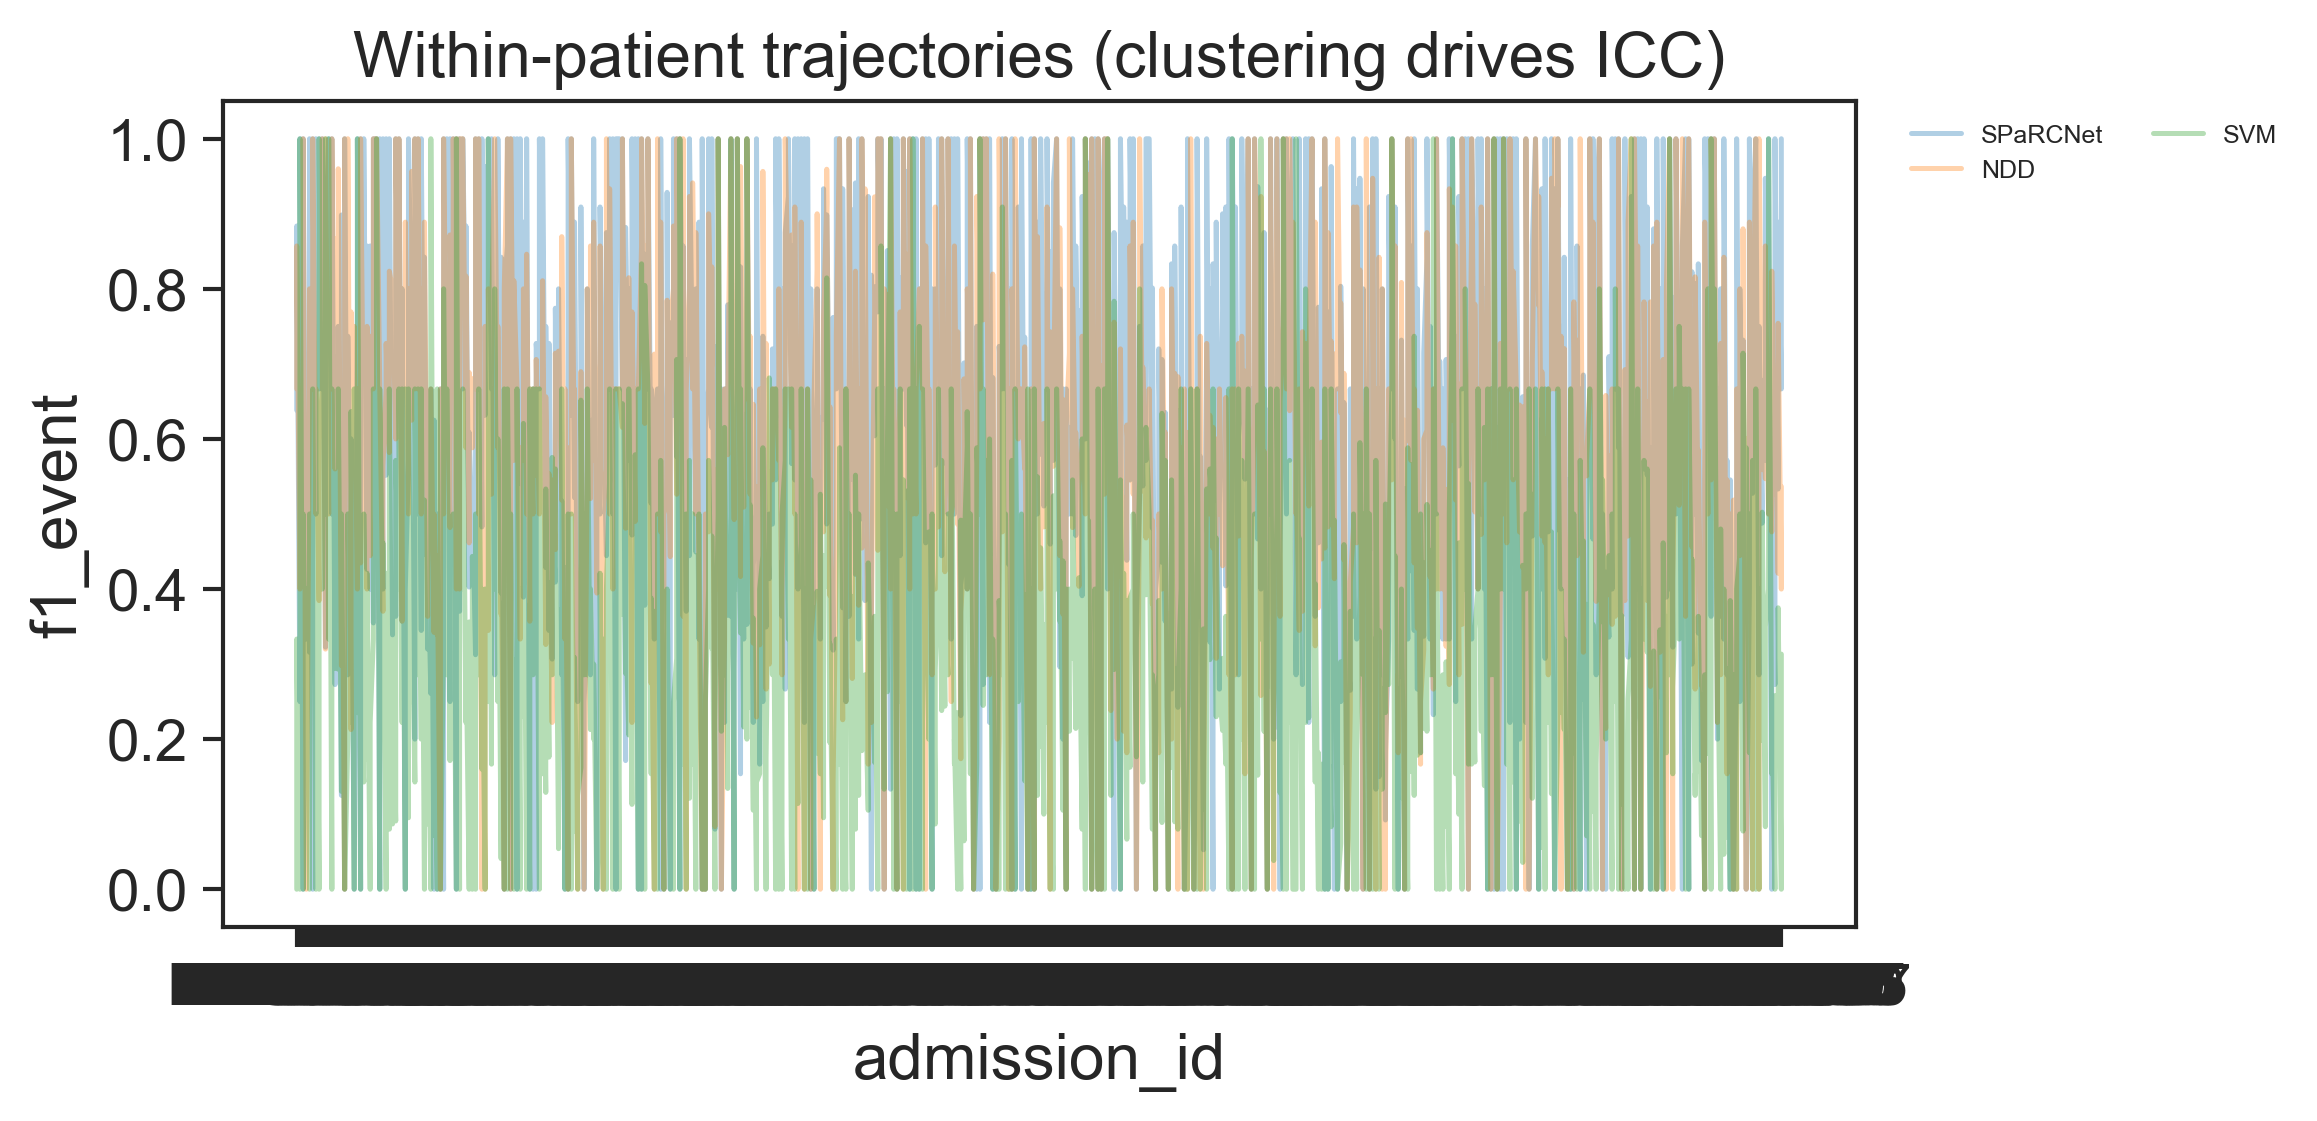

In [1316]:
# data: patient id, x (e.g. visit or time), outcome
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=sub, x="admission_id", y="f1_event",hue="model",
              estimator=None, alpha=0.35, ax=ax)
ax.set_title("Within-patient trajectories (clustering drives ICC)")
plt.legend(bbox_to_anchor=(1.02, 1), fontsize=6, ncol=2)
plt.tight_layout()

In [1322]:
def nakagawa_r2_lmm(result, exog_fe):
    """
    exog_fe: fixed-effects design matrix (same rows as data), no intercept column
             if your model uses implicit intercept; statsmodels gives fe_params
             with names - easier to use model.exog for the FE part.
    """
    # Fixed-effects linear predictor only (no BLUPs)
    fe = result.model.exog @ result.fe_params  # includes intercept in exog
    var_fe = float(np.var(fe, ddof=1))

    # Random effect variance(s): single random intercept -> 1x1 cov_re
    re_var = float(result.cov_re.iloc[0,0]) if result.cov_re.size else 0.0

    # Residual variance (Gaussian mixed model)
    sig2_res = float(result.scale)

    denom = var_fe + re_var + sig2_res
    r2_marginal = var_fe / denom
    r2_conditional = (var_fe + re_var) / denom
    return {
        "var_fixed": var_fe,
        "var_random_intercept": re_var,
        "var_residual": sig2_res,
        "R2_marginal": r2_marginal,
        "R2_conditional": r2_conditional,
        "pct_marginal": 100 * r2_marginal,
        "pct_conditional": 100 * r2_conditional,
    }

In [1323]:
mixed = smf.mixedlm(
    "f1_event ~  C(montage) +  C(model) ",   # fixed effects
    data=sub,
    groups=sub["admission_id"]     # random intercept per patient
).fit(method="lbfgs", reml=True)


stats = nakagawa_r2_lmm(mixed,mixed.model.exog)
print(stats)

{'var_fixed': 0.016867858726583765, 'var_random_intercept': 0.024204130996848157, 'var_residual': 0.04886869940389242, 'R2_marginal': 0.1875442459942109, 'R2_conditional': 0.4566563823553592, 'pct_marginal': 18.75442459942109, 'pct_conditional': 45.66563823553592}


In [1325]:
def incremental_marginal_r2(full_formula, reduced_formula, data, groups_col="admission_id"):
    mf = smf.mixedlm(full_formula, data, groups=data[groups_col]).fit(reml=True, method="lbfgs")
    mr = smf.mixedlm(reduced_formula, data, groups=data[groups_col]).fit(reml=True, method="lbfgs")
    return nakagawa_r2_lmm(mf, mf.model.exog)["R2_marginal"] - nakagawa_r2_lmm(mr, mr.model.exog)["R2_marginal"]

full = "f1_event ~  C(montage) +  C(model)"
red_p1 = "f1_event ~  C(model)"
red_p2 = "f1_event ~ C(montage) "

delta_p1 = incremental_marginal_r2(full, red_p1, sub)
delta_p2 = incremental_marginal_r2(full, red_p2, sub)
print("Delta marginal R2 due to pred1:", delta_p1)
print("Delta marginal R2 due to pred2:", delta_p2)

Delta marginal R2 due to pred1: -0.07853369999912765
Delta marginal R2 due to pred2: 0.1847688649819533


In [1327]:
m_full = smf.mixedlm(full, sub, groups=sub["admission_id"]).fit(reml=False, method="lbfgs")
m_red  = smf.mixedlm(red_p1, sub, groups=sub["admission_id"]).fit(reml=False, method="lbfgs")
lr = -2 * (m_red.llf - m_full.llf)
df_diff = m_full.df_modelwc - m_red.df_modelwc
from scipy import stats
p = 1 - stats.chi2.cdf(lr, df_diff)
print("LRT pred1:", lr, "df=", df_diff, "p=", p)

LRT pred1: -inf df= 4 p= 1.0


In [1227]:
mixed = smf.mixedlm(
    "f1_event ~  C(montage) +  C(model) ",   # fixed effects
    data=sub,
    groups=sub["admission_id"]     # random intercept per patient
).fit(method="lbfgs", reml=True)

ols   = smf.ols("f1_event ~ C(montage) +  C(model)", sub).fit()

lr = 2 * (mixed.llf - ols.llf)
p  = chi2.sf(lr, 1) / 2   # boundary correction


In [1140]:
print(mixed.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          f1_event
No. Observations:          6990             Method:                      ML      
No. Groups:                466              Scale:                       0.0488  
Min. group size:           15               Log-Likelihood:              138.5018
Max. group size:           15               Converged:                   Yes     
Mean group size:           15.0                                                  
---------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                              0.575    0.010  57.333 0.000  0.556  0.595
montage[T.full]                        0.029    0.008   3.460 0.001  0.013  0.045
montage[T.uneeg_diag_bilateral_front] 

In [1228]:
print(p)

0.0


In [1229]:
print(mixed.aic, ols.aic)

-259.00366619699344 1553.1746782265454


In [1143]:
full = smf.mixedlm("f1_event ~ montage + model ",  data=sub, groups=sub["admission_id"]).fit(reml=False)
no_var1 = smf.mixedlm("f1_event ~ model ",  data=sub, groups=sub["admission_id"]).fit(reml=False)

lr = 2 * (full.llf - no_var1.llf)
p  = chi2.sf(lr, df=1) / 2

In [1145]:
p

np.float64(1.1912006340545998e-09)

In [1144]:
print(full.aic, no_var1.aic)

-259.00366619699344 -231.37084969395073


In [1146]:
full = smf.mixedlm("f1_event ~ montage + model ",  data=sub, groups=sub["admission_id"]).fit(reml=False)
no_var2 = smf.mixedlm("f1_event ~ montage ",  data=sub, groups=sub["admission_id"]).fit(reml=False)

lr = 2 * (full.llf - no_var2.llf)
p  = chi2.sf(lr, df=1)/2

In [1147]:
print(full.aic, no_var2.aic)

-259.00366619699344 1765.210706794227


In [1222]:
full = smf.mixedlm("f1_event ~ C(montage, Treatment(reference='full')) + C(model, Treatment(reference='SVM')) ",  data=sub, groups=sub["admission_id"]).fit(reml=False)
inter = smf.mixedlm("f1_event ~ C(montage, Treatment(reference='full')) * C(model, Treatment(reference='SVM')) ",  data=sub, groups=sub["admission_id"]).fit(reml=False)

lr = 2 * (full.llf - inter.llf)
p  = chi2.sf(lr, df=1)/2

In [1223]:
print(p)

0.5


In [1224]:
print(full.aic, inter.aic)

-259.00366619699344 -299.89630518369086


In [1219]:
var_re = full.cov_re.iloc[0, 0]
var_resid = full.scale

icc = var_re / (var_re + var_resid)
print("ICC (person variance %):", icc)

ICC (person variance %): 0.33093046205400856


In [1220]:
var_re

np.float64(0.024148823029256132)

In [1221]:
var_resid

np.float64(0.04882367662934281)

In [1152]:

r2_full = np.var(full.fittedvalues) / np.var(sub["f1_event"])

r2_no_var1 = np.var(no_var1.fittedvalues) / np.var(sub["f1_event"])
r2_no_var2 = np.var(no_var2.fittedvalues) / np.var(sub["f1_event"])

print("Var1 contribution:", r2_full - r2_no_var1)
print("Var2 contribution:", r2_full - r2_no_var2)

Var1 contribution: 0.00312748379703387
Var2 contribution: 0.2076679527553465


In [1211]:
SELECTED_MONTAGES = ['full',
 'uneeg_diag_bilateral_front',
 'uneeg_diag_left_front',
 'uneeg_diag_right_front',
 'epiminder_2']
sub = df_p[df_p['montage'].isin(SELECTED_MONTAGES)]
sub = sub[sub['model'].isin(['SPaRCNet','NDD','SVM'])]
model = smf.mixedlm(
    "f1_event ~ C(montage, Treatment(reference='full')) + C(model, Treatment(reference='SVM'))",   # fixed effects
    data=sub,
    groups=sub["admission_id"]     # random intercept per patient
)

result = model.fit()
print(result.summary())

                                     Mixed Linear Model Regression Results
Model:                                MixedLM                    Dependent Variable:                    f1_event
No. Observations:                     6990                       Method:                                REML    
No. Groups:                           466                        Scale:                                 0.0489  
Min. group size:                      15                         Log-Likelihood:                        110.1219
Max. group size:                      15                         Converged:                             Yes     
Mean group size:                      15.0                                                                      
----------------------------------------------------------------------------------------------------------------
                                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------

In [1226]:
inter.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                                              Mixed Linear Model Regression Results
=================================================================================================================================================================
Model:                                                 MixedLM                                    Dependent Variable:                                    f1_event
No. Observations:                                      6990                                       Method:                                                ML      
No. Groups:                                            466                                        Scale:                                                 0.0484  
Min. group size:                                       15                                         Log-Likelihood:                                        166.9482
Max. group size:                                       15                                         Converged:                                             Yes     
Mean group size:                                       15.0                                                                                                      
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                               0.362    0.012 28.971 0.000  0.337  0.386
C(montage, Treatment(reference='full'))[T.epiminder_2]                                                                 -0.024    0.014 -1.656 0.098 -0.052  0.004
C(montage, Treatment(reference='full'))[T.uneeg_diag_bilateral_front]                                                  -0.065    0.014 -4.500 0.000 -0.093 -0.037
C(montage, Treatment(reference='full'))[T.uneeg_diag_left_front]                                                       -0.053    0.014 -3.680 0.000 -0.081 -0.025
C(montage, Treatment(reference='full'))[T.uneeg_diag_right_front]                                                      -0.064    0.014 -4.439 0.000 -0.092 -0.036
C(model, Treatment(reference='SVM'))[T.NDD]                                                                             0.217    0.014 15.077 0.000  0.189  0.246
C(model, Treatment(reference='SVM'))[T.SPaRCNet]                                                                        0.283    0.014 19.647 0.000  0.255  0.311
C(montage, Treatment(reference='full'))[T.epiminder_2]:C(model, Treatment(reference='SVM'))[T.NDD]                      0.040    0.020  1.986 0.047  0.001  0.080
C(montage, Treatment(reference='full'))[T.uneeg_diag_bilateral_front]:C(model, Treatment(reference='SVM'))[T.NDD]       0.064    0.020  3.161 0.002  0.024  0.104
C(montage, Treatment(reference='full'))[T.uneeg_diag_left_front]:C(model, Treatment(reference='SVM'))[T.NDD]            0.038    0.020  1.873 0.061 -0.002  0.078
C(montage, Treatment(reference='full'))[T.uneeg_diag_right_front]:C(model, Treatment(reference='SVM'))[T.NDD]           0.057    0.020  2.820 0.005  0.018  0.097
C(montage, Treatment(reference='full'))[T.epiminder_2]:C(model, Treatment(reference='SVM'))[T.SPaRCNet]                -0.056    0.020 -2.729 0.006 -0.096 -0.016
C(montage, Treatment(reference='full'))[T.uneeg_diag_bilateral_front]:C(model, Treatment(reference='SVM'))[T.SPaRCNet]  0.060    0.020  2.940 0.003  0.020  0.100
C(montage, Treatment(reference='full'))[T.uneeg_diag_left_front]:C(model, Treatment(reference='SVM'))[T.SPaRCNet]       0.028

In [1213]:

# predictions from fixed effects only
fe_only = full.model.predict(full.fe_params)

# predictions from full model
full_pred = full.fittedvalues

y = sub["f1_event"].values

var_total = np.var(y)

var_fe = np.var(fe_only)
var_full = np.var(full_pred)

r2_marginal = var_fe / var_total
r2_conditional = var_full / var_total

print("Marginal R2 (fixed effects):", r2_marginal)
print("Conditional R2 (fixed + random):", r2_conditional)

Marginal R2 (fixed effects): 0.18773305733337622
Conditional R2 (fixed + random): 0.4246057018284779


### ? Save threshold for each model

In [143]:
SELECTED_MONTAGES = list(MONTAGE_GROUPS.keys())

In [428]:
# get optimal threshold by F1 and at fixed FAR of 1/2/5/0.5
from timescoring.annotations import Annotation
from timescoring import scoring 
from joblib import Parallel, delayed
working_dir = os.path.abspath("")
sys.path.append(working_dir)
sys.path.append(os.path.join(working_dir,'funcs'))
from utils import *
from feat_funcs import *
from calc_metrics_update import compute_metrics
svm_path = os.path.join(working_dir,'SVM')
sys.path.append(svm_path)
from utils_baseline import (
        extract_features, train_one_class_svm, compute_novelty_scores,
        estimate_outlier_fraction, detect_seizure, apply_persistence
    )


model_stride = {'SPaRCNet':2, 'NDD':0.5, 'SVM':0.5,'Feat':5}

def compute_eventwise_scores(model_data, t):
    import warnings
    warnings.filterwarnings("ignore")
    all_scores = []
    for _, group in model_data.groupby('event_id'):
        true = group['label'].values
        prob = group['sz_prob'].values
        pred = (prob >= t).astype(int)
        pred = get_event_smoothed_pred(smooth_pred(pred), gap_num=int(4/stride), min_event_num=int(20/stride)) 
        if model == 'SVM':
            pred = apply_persistence(pred) 
        metrics = compute_metrics(true, pred, prob, stride)
        # labels = Annotation(true, 1/stride)
        # preds = Annotation(pred, 1/stride)
        # param = scoring.EventScoring.Parameters(
        #     toleranceStart=30,
        #     toleranceEnd=60,
        #     minOverlap=0,
        #     maxEventDuration=5 * 60,
        #     minDurationBetweenEvents=90)
        # scores = scoring.EventScoring(labels, preds, param)
        metrics['patient'] = group['patient'].iloc[0]
        all_scores.append(metrics)
    all_scores = pd.DataFrame(all_scores)
    agg_scores = []
    for name, group in all_scores.groupby(['patient']):
        recall = np.nanmean(group['recall_event'].values)
        fp = np.nanmean(group['fp'].values)
        perc = np.nansum(group['precision_event'] * group['num_pred']) / np.nansum(group['num_pred'])
        f1 = 2*recall*perc/(recall+perc)
        agg_scores.append([recall, fp, perc, f1])
    agg_scores = np.array(agg_scores)
    agg_scores[np.isnan(agg_scores)] = 0.0
    agg_scores[np.isinf(agg_scores)] = 0.0
    agg_scores = np.nanmean(np.array(agg_scores),axis=0)
    return agg_scores
    
threses = []
for model_ind, (model, model_data) in enumerate(prob_data.items()):
    model_data = prob_data[model]
    print(f'Calculating threses for model {model}')
    montages = ordered_montages(model_data, SELECTED_MONTAGES)
    mont_labels = [label(m) for m in montages]
    stride = model_stride[model]
    for mont in montages:
        print(mont)
        sub = model_data[model_data['montage'] == mont]
        true = sub['label'].values
        prob = sub['sz_prob'].values
        fpr, tpr, thres = roc_curve(true, prob)
        opt_thres_yodenj = thres[np.argmax(tpr-fpr)]
        # for 
        # recall, perc, thres = precision_recall_curve(true, prob)
        # f1 = 2*recall*perc/(recall+perc)
        # opt_thres_f1 = thres[np.argmax(f1)]
        N = 200
        if len(thres) > N:
            idx = np.linspace(0, len(thres) - 1, N).astype(int)
            thres = thres[idx]
        
        results = Parallel(n_jobs=40)(
            delayed(compute_eventwise_scores)(sub, t) for t in thres
        )
        sens, far, perc, f1 = zip(*results)
        sens = np.array(list(sens))
        far = np.array(list(far))
        perc = np.array(list(perc))
        f1 = np.array(list(f1))
        f1[0] = 0.0
        f1[-1] = 0.0
        opt_thres_f1 = thres[np.argmax(f1)]
        opt_thres_fars = []
        for far_thres in [0.5, 1, 2, 5]:
            if np.any(np.sign(far-far_thres)) == 0:
                opt_thres_fars.append(thres[np.where(np.sign(far-far_thres)==0)[0][-1]])
            else:
                if np.max(far) < far_thres:
                    opt_thres_fars.append(thres[-1])
                    print(f'Maximum FAR smaller than {far_thres}')
                elif np.min(far) > far_thres:
                    opt_thres_fars.append(thres[0])
                    print(f'Minimum FAR greater than {far_thres}')
                else:
                    far_ind = np.where(np.ediff1d(np.sign(far-far_thres)) > 0)[0][-1]
                    opt_thres_fars.append(thres[far_ind])
        opt_thres_far05, opt_thres_far1, opt_thres_far2, opt_thres_far5 = opt_thres_fars
            
        new_row = {'model':model,'montage':mont,
                        'thres_yodenj':opt_thres_yodenj,
                        'thres_f1':opt_thres_f1,
                        'thres_far0.5':opt_thres_far05, 
                        'thres_far1':opt_thres_far1, 
                        'thres_far2':opt_thres_far2, 
                        'thres_far5':opt_thres_far5}
        print(new_row)
        threses.append(new_row)
        
        

        
        

Calculating threses for model Feat
full
{'model': 'Feat', 'montage': 'full', 'thres_yodenj': np.float64(0.5038775685400865), 'thres_f1': np.float64(0.4915233118485588), 'thres_far0.5': np.float64(0.8195359248839424), 'thres_far1': np.float64(0.7245283010215702), 'thres_far2': np.float64(0.6072078252380204), 'thres_far5': np.float64(0.3076740844587323)}
epiminder_2
{'model': 'Feat', 'montage': 'epiminder_2', 'thres_yodenj': np.float64(0.4954038960728233), 'thres_f1': np.float64(0.577442917794758), 'thres_far0.5': np.float64(0.7953718123019528), 'thres_far1': np.float64(0.6969431686243066), 'thres_far2': np.float64(0.5478820520266593), 'thres_far5': np.float64(0.3114617337878065)}
uneeg_diag_left_front
{'model': 'Feat', 'montage': 'uneeg_diag_left_front', 'thres_yodenj': np.float64(0.5037131088658842), 'thres_f1': np.float64(0.5099443040832388), 'thres_far0.5': np.float64(0.7963836509613199), 'thres_far1': np.float64(0.691721904150893), 'thres_far2': np.float64(0.5671755341243228), 'thre

In [430]:
threses = pd.DataFrame(threses)

In [431]:
threses.to_csv(f'manuscript/f1_ver/threses_all.csv', header=False, mode='a',index=False)

### Pull all detections' average probability and max probability vs whether it's true detection or not

### SuppFigF F1score Correlation

In [9]:
from scipy.stats import spearmanr
def generate_figure2_corr(df_p, out_dir, suffix):
    """
    Figure 2: 5 selected montages × 3 models × 3 metrics.
    style = 'strip' (jittered dots) or 'violin'
    """
    models = _get_models(df_p, SELECTED_MODELS)
    montages = SELECTED_MONTAGES
    n_models  = len(models)

    fig, axes = plt.subplots(1, n_models,
        figsize=(4 * n_models, 5), squeeze=True
    )

    mont_labels = [label(m) for m in montages]
    from matplotlib.colors import LinearSegmentedColormap
    colors = ["#082a54", "#368899","#ffffff", "#F47C6D", "#e02b35"]
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

    
    for row_i, model in enumerate(models):
        sub = df_p[df_p["model"] == model] if "model" in df_p.columns else df_p
        sub = sub.drop(columns=['admission_id','model'])
        sub = sub[montages]
        ax = axes[row_i]
        # corr = np.corrcoef(sub, rowvar=False)
        corr, p_value = spearmanr(sub.values, axis=0)

        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

        sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap, 
                    linewidths=0.4, linecolor="white",
                    cbar=False,
                    ax=ax, vmin=-1, vmax=1,
                    cbar_kws={},
                    annot_kws={"size": 12},
                    )
        ax.set_title(f"{model}", fontweight="bold", pad=8)
        ax.set_xlabel("")
        ax.set_xticklabels(mont_labels, rotation=40, ha='right', fontsize=12)
        ax.set_yticklabels(mont_labels, rotation=0, fontsize=12)
        if row_i != 0:
            ax.set_yticklabels([])
            ax.yaxis.set_tick_params(labelleft=False)
        # ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    # 🔑 create colorbar axis
    cax = fig.add_axes([0.99, 0.27, 0.01, 0.57])#[0.985, 0.10, 0.015, 0.55]
    
    # use one of the heatmaps to generate colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_clim(-1, 1)
    
    cbar = fig.colorbar(
        sm,
        cax=cax,
        label='Correlation'
    )
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_ticks([-1, 0, 1])
    
    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"SuppFigF_corr_{suffix}_spearman")


In [10]:
SELECTED_MONTAGES = [
    "full",
    "uneeg_diag_bilateral_front",
    "uneeg_diag_left_front",
    "uneeg_diag_right_front",
    "epiminder_2",
]
SELECTED_MODELS = ['SPaRCNet','NDD','SVM']
for suffix in ['f1_event','auroc','auprc']:
    pivoted = df_p[df_p['model'].isin(SELECTED_MODELS)&df_p['montage'].isin(SELECTED_MONTAGES)].pivot_table(
        index=["admission_id","model"],   # group by x and y
        columns=["montage"],        # new column headers
        values=suffix,         # values to fill
        aggfunc="first"     # or 'sum', 'mean', etc. depending on your case
    ).reset_index()
    generate_figure2_corr(pivoted, out_dir, suffix)

  Saved: manuscript/f1_ver_update/SuppFigF_corr_f1_event_spearman.png
  Saved: manuscript/f1_ver_update/SuppFigF_corr_f1_event_spearman.svg
  Saved: manuscript/f1_ver_update/SuppFigF_corr_auroc_spearman.png
  Saved: manuscript/f1_ver_update/SuppFigF_corr_auroc_spearman.svg
  Saved: manuscript/f1_ver_update/SuppFigF_corr_auprc_spearman.png
  Saved: manuscript/f1_ver_update/SuppFigF_corr_auprc_spearman.svg


### Advanced methods for testing performance consistency

In [1354]:
import pingouin as pg

In [1372]:
from scipy.stats import spearmanr
def generate_iic(model_data, out_dir, suffix):
    """
    Figure 2: 5 selected montages × 3 models × 3 metrics.
    style = 'strip' (jittered dots) or 'violin'
    """
    models = SELECTED_MODELS
    montages = SELECTED_MONTAGES
    n_models  = len(model_data)

    fig, axes = plt.subplots(1, n_models,
        figsize=(4 * n_models, 5), squeeze=True
    )

    mont_labels = [label(m) for m in montages]
    from matplotlib.colors import LinearSegmentedColormap
    colors = ["#082a54", "#368899","#ffffff", "#F47C6D", "#e02b35"]
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

    for row_i, (model, corr) in enumerate(model_data.items()):
        ax = axes[row_i]
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
        sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap, 
                    linewidths=0.4, linecolor="white",
                    cbar=False,
                    ax=ax, vmin=-1, vmax=1,
                    cbar_kws={},
                    annot_kws={"size": 12},
                    )
        ax.set_title(f"{model}", fontweight="bold", pad=8)
        ax.set_xlabel("")
        ax.set_xticklabels(mont_labels, rotation=40, ha='right', fontsize=12)
        ax.set_yticklabels(mont_labels, rotation=0, fontsize=12)
        if row_i != 0:
            ax.set_yticklabels([])
            ax.yaxis.set_tick_params(labelleft=False)
        # ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    # 🔑 create colorbar axis
    cax = fig.add_axes([0.99, 0.27, 0.01, 0.57])#[0.985, 0.10, 0.015, 0.55]
    
    # use one of the heatmaps to generate colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_clim(-1, 1)
    
    cbar = fig.colorbar(
        sm,
        cax=cax,
        label='Correlation'
    )
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_ticks([-1, 0, 1])
    
    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"SuppFigG_corr_{suffix}")


In [1365]:
# ICC(2,1): agreement, random raters (recommended)
icc_mat = {}
for model in SELECTED_MODELS:
    tmp_mat = np.eye(len(SELECTED_MONTAGES))
    sub = df_p[df_p['model']==model]
    for i in range(len(SELECTED_MONTAGES)):
        for j in range(i+1, len(SELECTED_MONTAGES)):
            tmp = sub[sub['montage'].isin([SELECTED_MONTAGES[i],SELECTED_MONTAGES[j]])]
            icc = pg.intraclass_corr(data=tmp,
                                     targets="admission_id",
                                     raters="montage",
                                     ratings="f1_event")
            tmp_mat[i,j] = icc[icc["Type"] == "ICC(A,1)"]['ICC'].iloc[0]
            tmp_mat[j,i] = icc[icc["Type"] == "ICC(A,1)"]['ICC'].iloc[0]
    icc_mat[model] = tmp_mat


In [1373]:
generate_iic(icc_mat, out_dir, 'icc')

  Saved: manuscript/f1_ver_update/SuppFigG_corr_icc.png
  Saved: manuscript/f1_ver_update/SuppFigG_corr_icc.svg


In [1374]:
pivoted = df_p.pivot_table(
    index=["admission_id","model"],   # group by x and y
    columns="montage",        # new column headers
    values="f1_event",         # values to fill
    aggfunc="first"     # or 'sum', 'mean', etc. depending on your case
).reset_index()
pivoted = pivoted.sort_values(['model','admission_id'])
pivoted = pivoted[['admission_id','model']+SELECTED_MONTAGES]

In [1387]:
import statsmodels.api as sm


for model_name in SELECTED_MODELS:
    print(model_name)
    sub = pivoted[pivoted['model']==model_name]
    X = sm.add_constant(sub["full"])
    for m in SELECTED_MONTAGES[1:]:
        sub['diff_'+m] = sub[m]-sub['full']
        model = sm.OLS(sub[m], X).fit()
        print('Mean:', sub['diff_'+m].mean(), 'Median:', sub['diff_'+m].median())
        print('Std:', sub['diff_'+m].std())
        print(model.summary())

SPaRCNet
Mean: -0.00492615581750588 Median: 0.0
Std: 0.34724805609559395
                                OLS Regression Results                                
Dep. Variable:     uneeg_diag_bilateral_front   R-squared:                       0.110
Model:                                    OLS   Adj. R-squared:                  0.109
Method:                         Least Squares   F-statistic:                     57.63
Date:                        Sun, 12 Apr 2026   Prob (F-statistic):           1.75e-13
Time:                                05:22:11   Log-Likelihood:                -24.205
No. Observations:                         466   AIC:                             52.41
Df Residuals:                             464   BIC:                             60.70
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                 coef    std err          t      P>|t|   

In [1408]:
# scatter plot
def generate_scatter_plot(pivoted, out_dir):
    n_models = len(SELECTED_MODELS)
    montages = [m for m in SELECTED_MONTAGES if m != 'full']
    mont_labels = [label(m) for m in montages]
    n_montages = len(montages)
    colors = ["#082a54","#e02b35", "#F47C6D", "#368899"]
    fig,axs = plt.subplots(n_models,n_montages,figsize=(3*n_montages,2.5*n_models))
    for row_i, model_name in enumerate(SELECTED_MODELS):
        sub = pivoted[pivoted['model']==model_name]
        for col_i, m in enumerate(SELECTED_MONTAGES[1:]):
            ax = axs[row_i, col_i]
            ax.scatter(sub["full"], sub[m], color = colors[col_i], s=20, alpha = 0.3)
            if col_i != 0:
                ax.set_yticklabels([])
            if row_i < n_models-1:
                ax.set_xticklabels([])
            if row_i == 0:
                ax.set_title(mont_labels[col_i], fontweight="bold", fontsize=12)
            if col_i == 0:
                ax.set_ylabel(model_name, fontweight="bold", fontsize=12)
                
            # plt.ylabel("Reduced montage F1")
            # identity line
            lims = [0, 1]
            ax.plot(lims, lims, linestyle="--", color = 'k',linewidth=1)
    fig.supxlabel("Full montage F1", fontsize=14, fontweight="bold")
    fig.supylabel("Reduced montage F1", fontsize=14, fontweight="bold")
    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"SuppFigH_scatter")


In [1409]:
generate_scatter_plot(pivoted, out_dir)

  Saved: manuscript/f1_ver_update/SuppFigH_scatter.png
  Saved: manuscript/f1_ver_update/SuppFigH_scatter.svg


### SuppFigE latency

In [1290]:

def extract_seiz_ranges(true_data):
    diff_data = np.diff(np.concatenate([[0], np.squeeze(true_data), [0]]))
    starts = np.where(diff_data == 1)[0]
    stops = np.where(diff_data == -1)[0]
    return list(zip(starts, stops))


In [1291]:
sz_list = pd.read_csv(seizure_data)
sz_list['sz_dura'] = sz_list['off']-sz_list['ueoeec']
SELECTED_MONTAGES = ['full',
 'uneeg_diag_bilateral_front',
 'uneeg_diag_left_front',
 'uneeg_diag_right_front',
 'epiminder_2']
model_stride = {'SPaRCNet':2, 'NDD':0.5, 'SVM':0.5}

In [1292]:
lat_data = []
for model_name, rdir in results_dir_map.items():
    stride = model_stride[model_name]
    setting = setting_map[model_name]
    fs = 1/stride
    pred_dir = os.path.join(rdir,'pred',setting)
    print(f"\n=== Loading {model_name} from {pred_dir} ===")
    montages = os.listdir(pred_dir)
    use_montages = [m for m in SELECTED_MONTAGES if m in montages]
    for m in use_montages:
        for i, (_, row) in tqdm(enumerate(sz_list.iterrows())):
            f = os.path.join(pred_dir, m, row['event_patient_id']+'.csv')
            tmp = pd.read_csv(f)
            tmp = tmp[['pred','label']]
            true_sz = extract_seiz_ranges(tmp['label'].values)
            true_sz_expand = (int(true_sz[0][0]-int(30*fs)), int(true_sz[0][1]+int(60*fs)))
            if tmp['pred'].iloc[true_sz_expand[0]:true_sz_expand[1]].any():
                pred_sz = extract_seiz_ranges(tmp['pred'].values)
                pred_sz = [sz for sz in pred_sz if sz[0] <= true_sz_expand[1] and sz[1] >= true_sz_expand[0]]
                lats = np.abs([sz[0]-true_sz[0][0] for sz in pred_sz])
                ind = np.argmin(lats)
                lat = (pred_sz[ind][0] - true_sz[0][0])*stride
            else:
                lat = np.nan
            lat_data.append({'event_patient_id':row['event_patient_id'],'model': model_name, 'montage':m, 'latency':lat, 'duration': row['sz_dura']})    
lat_data = pd.DataFrame(lat_data)        
lat_data['detected'] = ~lat_data['latency'].isna()
lat_data.to_csv(f'{out_dir}/latency.csv', index=False)


=== Loading SPaRCNet from /mnt/sauce/littlab/users/haoershi/limited_montage/sparcnet_results/pred/thres_optimal_f1 ===


1683it [00:02, 714.71it/s]
1683it [00:02, 714.04it/s]
1683it [00:02, 711.89it/s]
1683it [00:02, 711.45it/s]
1683it [00:02, 706.51it/s]



=== Loading NDD from /mnt/sauce/littlab/users/haoershi/limited_montage/dynasd_results/pred/thres_optimal_f1_avg ===


1683it [00:03, 483.52it/s]
1683it [00:03, 487.99it/s]
1683it [00:03, 486.91it/s]
1683it [00:03, 485.96it/s]
1683it [00:03, 484.38it/s]



=== Loading SVM from /mnt/sauce/littlab/users/haoershi/limited_montage/svm_results/pred/thres_optimal_f1_avg ===


1683it [00:03, 503.33it/s]
1683it [00:03, 512.04it/s]
1683it [00:03, 522.56it/s]
1683it [00:03, 515.37it/s]
1683it [00:03, 509.77it/s]


In [1293]:

def _render_box_lat(df_p, out_dir, style="strip",suffix=''):
    models = _get_models(df_p, SELECTED_MODELS)
    montages = ordered_montages(df_p, SELECTED_MONTAGES)
    if not montages:
        print("[WARN] No selected montages found for Fig 2. Skipping.")
        return

    metrics = [
        ("latency",     "Latency (sec)")
    ]
    available_metrics = [(c, n) for c, n in metrics if c in df_p.columns]
    col, name = available_metrics[0]
    n_metrics = len(available_metrics)
    n_models  = len(models)

    fig, axes = plt.subplots(n_metrics, n_models,
        figsize=(4 * n_models, 5*n_metrics), squeeze=True
    )

    df_p["montage_label"] = df_p["montage"].map(label)
    mont_labels = [label(m) for m in montages]
    for row_i, model in enumerate(models):
        sub = df_p[df_p["model"] == model] if "model" in df_p.columns else df_p
        sub = sub[sub["montage"].isin(montages)].copy()
        ax = axes[row_i]
        if style == "violin":
            sns.violinplot(
                data=sub, x="montage_label", y=col, order = mont_labels,
                palette={label(m): MONTAGE_PALETTE[m] for m in montages},
                inner=None, cut=0, linewidth=0.8, alpha=0.6, ax=ax,
            )
        elif style == 'strip':  # strip
            sns.stripplot(
                data=sub, x="montage_label", y=col, order = mont_labels,
                palette={label(m): MONTAGE_PALETTE[m] for m in montages}, 
                jitter=0.2, size=3, alpha=0.3, zorder=1, ax=ax,
            )
    
            sns.pointplot(
                    data=sub, x="montage_label", y=col, order = mont_labels,
                    # palette={label(m): mont_color[m] for m in montages},
                    estimator='mean',
                    dodge=False, linestyle="none", errorbar=("ci", 95),
                    marker="_", markersize=25, markeredgewidth=3,zorder=10,errwidth=1,color='black', ax=ax
                )
        elif style == 'box':
            sns.boxplot(
                    data=sub, x="montage_label", y=col, order = mont_labels,
                    palette={label(m): MONTAGE_PALETTE[m] for m in montages},#sns.color_palette("Paired"),#
                    notch=False, showcaps=True,showfliers=False,width=0.5,
                    # boxprops={'edgeco'}
                    medianprops={"color": "black", "linewidth": 2},zorder=0,
                    ax=ax
                )
            
            for patch in ax.patches:
                color = patch.get_facecolor()
                patch.set_facecolor((*color[:3], 0.5)) # transparent
                # patch.set_edgecolor(color)
                patch.set_linewidth(1)
            # for i, line in enumerate(ax.lines):
            #     color = ax.patches[i // 6].get_edgecolor()  # each box has ~6 lines
            #     line.set_color(color)
            #     line.set_linewidth(2)
    
            sns.stripplot(
                data=sub, x="montage_label", y=col, order = mont_labels,
                palette={label(m): MONTAGE_PALETTE[m] for m in montages},#sns.color_palette("Paired"),#
                jitter=0.15, size=4, alpha=0.5, zorder=1, ax=ax,
            )
    
            
        elif style == 'raincloud':
            pt.RainCloud(
                    x="montage_label", y=col, data=sub, order=mont_labels, hue_order=mont_labels,
                    palette=[MONTAGE_PALETTE[m] for m in montages], #sns.color_palette("viridis"),#
                    bw=0.2, width_viol=0.6, ax=ax, orient="v", alpha=0.7, move=0.25, offset=0.1, jitter=0.12,
                    box_showfliers=False, rain_alpha=0.5
                )
        ax.set_ylim((-250,250))
        ax.set_title(f"{model}", fontweight="bold", pad=8)
        ax.set_ylabel(name if row_i == 0 else "", fontweight="bold")
        ax.set_xlabel("")
        ax.set_xticklabels(mont_labels, rotation=40, ha='right', fontsize=12)
        if row_i != 0:
            ax.set_yticklabels([])
            ax.yaxis.set_tick_params(labelleft=False)
        # ax.yaxis.grid(True, linestyle="--", alpha=0.5)

    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"SuppFigE_latency_{style}")

In [1294]:
_render_box_lat(lat_data, out_dir, 'raincloud')

  Saved: manuscript/f1_ver_update/SuppFigE_latency_raincloud.png
  Saved: manuscript/f1_ver_update/SuppFigE_latency_raincloud.svg


In [1295]:
from tableone import TableOne
lat_data['join'] = lat_data[['model','montage']].apply(lambda x:'_'.join(x), axis=1)
table1 = TableOne(lat_data, columns=['latency'], groupby='join', missing=True, htest_name=False, pval=True, decimals = 3)
table1.tableone['Grouped by join'].T

,n,"latency, mean (SD)"
,,
Missing,,8356
Overall,25245,-23.649 (95.613)
NDD_epiminder_2,1683,-24.141 (87.074)
NDD_full,1683,-39.384 (102.388)
NDD_uneeg_diag_bilateral_front,1683,-18.167 (84.222)
NDD_uneeg_diag_left_front,1683,-32.578 (94.412)
NDD_uneeg_diag_right_front,1683,-21.666 (89.060)
SPaRCNet_epiminder_2,1683,4.255 (44.213)
SPaRCNet_full,1683,5.823 (40.444)


### Get statistical data

In [28]:
df = df_p.pivot_table(
    index=["admission_id","model"],   # group by x and y
    columns="montage",        # new column headers
    values="f1_event",         # values to fill
    aggfunc="first"     # or 'sum', 'mean', etc. depending on your case
).reset_index()

In [29]:
df = df.sort_values(['model','admission_id'])

In [30]:
p_info

,num_sz_event,avg_sz_dura,num_iic_segment,admission_id,patient_id,age,gender,laterality,location,epilepsy_type,diagnosis,race1,ethnicity,marital_status,employment_status,occupation,smoking_status
0,3,96.244792,3,EMU0878,3.0,24.387748,Female,Left,Multifocal,Mixed,epilepsy,Unknown,Not Hispanic or Latino,Single,Disabled,NaN,NEVER
1,1,47.273438,1,EMU1003,129.0,27.519367,Female,Left,Frontal,Focal,epilepsy,White,Not Hispanic or Latino,Single,Part Time,NaN,NEVER
2,1,57.234375,1,EMU1036,98.0,60.987659,Female,Left,Temporal,Focal,epilepsy,White,Not Hispanic or Latino,Married,Retired,NaN,NEVER
3,1,58.250000,1,EMU1049,75.0,33.778892,Male,Right,Temporal,Focal,epilepsy,Black or African American,Not Hispanic or Latino,Divorced,Disabled,NaN,FORMER
4,1,198.242187,1,EMU1061,328.0,72.796385,Female,Nan,Nan,Focal,epilepsy,East Indian,Not Hispanic or Latino,Married,Retired,NaN,NEVER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,1,150.957031,1,EMU3033,1535.0,25.893836,Male,Nan,Nan,Generalized,epilepsy,Black or African American,Not Hispanic or Latino,Single,Not Employed,NaN,NEVER
462,3,43.460937,3,EMU3036,2130.0,58.329452,Female,Left,Temporal,Focal,NaN,White,Patient Declined,Married,Unknown,NaN,EVERY DAY
463,7,26.045201,7,EMU3040,2080.0,37.680137,Female,Left,Temporal,Focal,NaN,White,Not Hispanic or Latino,Married,Unknown,NaN,NEVER
464,5,81.109375,5,EMU3045,2132.0,26.856299,Female,Nan,Nan,Nan,NaN,White,Not Hispanic or Latino,Married,Part Time,Sales,NEVER


In [31]:
df = df.merge(p_info[['admission_id','laterality','location','epilepsy_type']],on='admission_id',how='left') 

In [32]:
df

,admission_id,model,ceribell,epiminder_2,full,uneeg_bilateral_back2,uneeg_bilateral_front2,uneeg_diag_bilateral_back,uneeg_diag_bilateral_front,uneeg_diag_left_back,...,uneeg_left_back,uneeg_left_front,uneeg_right_back,uneeg_right_front,uneeg_vert_bilateral,uneeg_vert_left,uneeg_vert_right,laterality,location,epilepsy_type
0,EMU0878,NDD,0.705882,0.666667,0.758621,0.628571,0.900000,0.718447,0.857143,0.730769,...,0.736842,0.909091,1.000000,0.800000,0.857143,0.736842,0.833333,Left,Multifocal,Mixed
1,EMU1003,NDD,0.500000,0.666667,0.666667,0.500000,0.500000,0.500000,0.666667,0.500000,...,0.500000,0.400000,1.000000,0.666667,0.500000,0.500000,1.000000,Left,Frontal,Focal
2,EMU1036,NDD,1.000000,0.666667,1.000000,0.666667,0.666667,0.666667,0.666667,0.666667,...,0.666667,1.000000,0.666667,0.666667,0.666667,0.500000,0.666667,Left,Temporal,Focal
3,EMU1049,NDD,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Right,Temporal,Focal
4,EMU1061,NDD,0.800000,0.666667,0.666667,0.666667,0.800000,0.800000,0.800000,0.800000,...,0.666667,0.666667,0.666667,0.500000,1.000000,0.800000,1.000000,Nan,Nan,Focal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1393,EMU3033,SVM,0.400000,0.666667,1.000000,0.285714,0.400000,0.400000,0.400000,0.000000,...,0.000000,0.000000,0.000000,0.400000,0.400000,0.000000,0.400000,Nan,Nan,Generalized
1394,EMU3036,SVM,0.250000,0.250000,0.363636,0.181818,0.222222,0.181818,0.166667,0.307692,...,0.181818,0.363636,0.181818,0.222222,0.166667,0.166667,0.222222,Left,Temporal,Focal
1395,EMU3040,SVM,0.413793,0.450512,0.250000,0.344828,0.248889,0.370370,0.318021,0.384615,...,0.384615,0.315036,0.359281,0.333333,0.296296,0.400000,0.322581,Left,Temporal,Focal
1396,EMU3045,SVM,0.210526,0.307692,0.442211,0.240000,0.222222,0.210526,0.375000,0.320000,...,0.260870,0.260870,0.222222,0.235294,0.095238,0.400000,0.235294,Nan,Nan,Nan


In [33]:
SELECTED_MONTAGES = ['full',
 'epiminder_2',
 'uneeg_diag_left_front',
 'uneeg_diag_right_front',
 'uneeg_diag_bilateral_front']

In [34]:
df = df[['admission_id','model']+SELECTED_MONTAGES+['laterality','location','epilepsy_type']]

In [35]:
df

,admission_id,model,full,epiminder_2,uneeg_diag_left_front,uneeg_diag_right_front,uneeg_diag_bilateral_front,laterality,location,epilepsy_type
0,EMU0878,NDD,0.758621,0.666667,0.740741,0.800000,0.857143,Left,Multifocal,Mixed
1,EMU1003,NDD,0.666667,0.666667,0.400000,0.666667,0.666667,Left,Frontal,Focal
2,EMU1036,NDD,1.000000,0.666667,0.666667,0.666667,0.666667,Left,Temporal,Focal
3,EMU1049,NDD,0.000000,0.000000,0.000000,0.000000,0.000000,Right,Temporal,Focal
4,EMU1061,NDD,0.666667,0.666667,0.800000,0.666667,0.800000,Nan,Nan,Focal
...,...,...,...,...,...,...,...,...,...,...
1393,EMU3033,SVM,1.000000,0.666667,0.500000,0.400000,0.400000,Nan,Nan,Generalized
1394,EMU3036,SVM,0.363636,0.250000,0.153846,0.181818,0.166667,Left,Temporal,Focal
1395,EMU3040,SVM,0.250000,0.450512,0.303030,0.266667,0.318021,Left,Temporal,Focal
1396,EMU3045,SVM,0.442211,0.307692,0.333333,0.266667,0.375000,Nan,Nan,Nan


In [36]:
df.to_csv(f'{out_dir}/statistics_data.csv',index=False)

In [1304]:
df[df['model']=='NDD']['laterality'].value_counts()

laterality
Left         167
Nan          126
Right        108
Bilateral     65
Name: count, dtype: int64

In [573]:
df_p[(df_p['model']==model)&(df_p['montage']=='full')]['fp'].mean()

np.float64(2.9241456654077944)

In [38]:
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from itertools import combinations
from statsmodels.stats.multitest import multipletests
# Example: rows = subjects, cols = methods/conditions
for model in ['SPaRCNet', 'NDD', 'SVM']:
    print(model)
    sub = df[df['model']==model][SELECTED_MONTAGES].values
    
    # unpack columns
    stat, p = friedmanchisquare(*[sub[:, i] for i in range(sub.shape[1])])
    
    print("Friedman stat:", stat)
    print("p-value:", p)

    if p <= 0.05:
        n_methods = sub.shape[1]
        pairs = list(combinations(range(n_methods), 2))

        stats = []
        pvals = []
        rvals = []
        pair_names = []
        
        for i, j in pairs:
            stat, p = wilcoxon(sub[:, i], sub[:, j])
            diff = sub[:, i] - sub[:, j]
            n = np.sum(diff != 0)
            
            # Approximate Z
            mean_W = n * (n + 1) / 4
            std_W = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
            
            Z = (stat - mean_W) / std_W
            
            r = Z / np.sqrt(n)

            stats.append(stat)
            pvals.append(p)
            rvals.append(r)
            pair_names.append(f"{SELECTED_MONTAGES[i]} vs {SELECTED_MONTAGES[j]}")

        reject, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')

        results = pd.DataFrame({
            "comparison": pair_names,
            "stat": stats,
            "effect_size": rvals,
            "pval": np.round(pvals,3),
            "pval_fdr_bh": np.round(pvals_corrected,3),
            "significant": reject
        })
        
        print(results)

SPaRCNet
Friedman stat: 78.60022203034274
p-value: 3.447346126739185e-16
                                          comparison     stat  effect_size  \
0                                full vs epiminder_2  27127.0    -0.274450   
1                      full vs uneeg_diag_left_front  28871.0    -0.079154   
2                     full vs uneeg_diag_right_front  28815.0    -0.250042   
3                 full vs uneeg_diag_bilateral_front  37057.5    -0.057690   
4               epiminder_2 vs uneeg_diag_left_front  31649.0    -0.196086   
5              epiminder_2 vs uneeg_diag_right_front  37614.0    -0.011559   
6          epiminder_2 vs uneeg_diag_bilateral_front  26734.5    -0.274132   
7    uneeg_diag_left_front vs uneeg_diag_right_front  28305.0    -0.209781   
8  uneeg_diag_left_front vs uneeg_diag_bilateral_...  36663.5    -0.006952   
9  uneeg_diag_right_front vs uneeg_diag_bilateral...  17527.0    -0.377662   

    pval  pval_fdr_bh  significant  
0  0.000        0.000         T

### Pull patients without single detection

In [19]:
pivoted

montage,admission_id,model,epiminder_2,full,uneeg_diag_bilateral_front,uneeg_diag_left_front,uneeg_diag_right_front
0,EMU0878,NDD,0.272329,0.196955,0.352889,0.283489,0.410169
1,EMU0878,SPaRCNet,0.525931,0.224212,0.562263,0.399156,0.673975
2,EMU0878,SVM,0.047802,0.083044,0.047701,0.050279,0.048806
3,EMU1003,NDD,0.817392,0.665838,0.732523,0.695726,0.845482
4,EMU1003,SPaRCNet,0.679503,0.718826,0.813838,0.823747,0.835037
...,...,...,...,...,...,...,...
1393,EMU3045,SPaRCNet,0.510558,0.707352,0.590427,0.638862,0.375530
1394,EMU3045,SVM,0.319397,0.316273,0.155354,0.142324,0.141908
1395,EMU3047,NDD,0.367738,0.341815,0.232809,0.275986,0.209636
1396,EMU3047,SPaRCNet,0.664765,0.973138,0.794076,0.692918,0.741163


In [53]:
pivoted = df_p.pivot_table(
    index=["admission_id","model"],   # group by x and y
    columns="montage",        # new column headers
    values="recall_event",         # values to fill
    aggfunc="first"     # or 'sum', 'mean', etc. depending on your case
).reset_index()
pivoted = pivoted.sort_values(['model','admission_id'])
pivoted = pivoted[['admission_id','model']+SELECTED_MONTAGES]
pivoted = pivoted.merge(p_info[['admission_id','laterality','location','epilepsy_type']],on='admission_id',how='left') 
pivoted['no_detection'] = (pivoted[SELECTED_MONTAGES]==0).sum(axis=1) >= 1


In [50]:
pivoted2 = df_p.pivot_table(
    index=["admission_id","model"],   # group by x and y
    columns="montage",        # new column headers
    values="auroc",         # values to fill
    aggfunc="first"     # or 'sum', 'mean', etc. depending on your case
).reset_index()
pivoted2 = pivoted2.sort_values(['model','admission_id'])
pivoted2 = pivoted2[['admission_id','model']+SELECTED_MONTAGES]
pivoted2 = pivoted2.merge(p_info[['admission_id','laterality','location','epilepsy_type']],on='admission_id',how='left') 
pivoted2['poor'] = (pivoted2[SELECTED_MONTAGES]<0.5).sum(axis=1) >= 1


In [59]:
from tableone import TableOne
model = 'NDD'
sub = pivoted[pivoted['model']==model]
# lat_data['join'] = lat_data[['model','montage']].apply(lambda x:'_'.join(x), axis=1)
table1 = TableOne(sub, columns=['epilepsy_type','laterality','location'], groupby='no_detection', missing=True, htest_name=False, pval=True, decimals = 3)
table1.tableone['Grouped by no_detection'].to_csv(f'{out_dir}/{model}_recall_no_detect.csv')

In [57]:
from tableone import TableOne
model = 'SPaRCNet'
sub2 = pivoted2[pivoted2['model']==model]
# lat_data['join'] = lat_data[['model','montage']].apply(lambda x:'_'.join(x), axis=1)
table1 = TableOne(sub2, columns=['epilepsy_type','laterality','location'], groupby='poor', missing=True, htest_name=False, pval=True, decimals = 3)
table1.tableone['Grouped by poor'].to_csv(f'{out_dir}/{model}_auroc_low0.5.csv')

In [37]:
model = 'NDD'
no_detection[no_detection['model']==model
print(no_detection[no_detection['model']==model]['laterality'].value_counts())
print(no_detection[no_detection['model']==model]['location'].value_counts())
print(no_detection[no_detection['model']==model]['epilepsy_type'].value_counts())

laterality
Left         18
Right        12
Nan          12
Bilateral     4
Name: count, dtype: int64
location
Temporal      27
Nan           12
Frontal        4
Multifocal     3
Name: count, dtype: int64
epilepsy_type
Focal          37
Nan             6
Generalized     2
Mixed           1
Name: count, dtype: int64


In [ ]:
ineffective = sub[sub['auroc']<0.5]

In [18]:
no_detection[no_detection['model']=='SPaRCNet']

,admission_id,total_dura,tn,num_pred,num_sz,total_sz_dura,avg_sz_dura,auprc,auroc,recall_event,fp,precision_event,f1_event,montage,model
484,EMU1498,34.633333,0.969697,3,2,1.633333,0.816667,0.072953,0.508699,0.0,3.459925,0.0,0.0,epiminder_2,SPaRCNet
492,EMU1613,18.366667,1.000000,0,1,0.933333,0.933333,0.134887,0.443253,0.0,0.000000,0.0,0.0,epiminder_2,SPaRCNet
509,EMU1717,161.600000,0.984517,3,8,10.900000,1.362500,0.138279,0.692975,0.0,1.097629,0.0,0.0,epiminder_2,SPaRCNet
510,EMU1718,42.933333,0.985460,1,3,1.666667,0.555556,0.046084,0.459515,0.0,1.734104,0.0,0.0,epiminder_2,SPaRCNet
539,EMU1813,36.733333,0.881459,7,2,3.833333,1.916667,0.101456,0.507343,0.0,6.857588,0.0,0.0,epiminder_2,SPaRCNet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7424,EMU2931,20.033333,1.000000,0,1,0.500000,0.500000,0.022168,0.382366,0.0,0.000000,0.0,0.0,uneeg_diag_left_front,SPaRCNet
7426,EMU2934,19.766667,0.979522,1,1,0.233333,0.233333,0.014929,0.463920,0.0,3.040541,0.0,0.0,uneeg_diag_left_front,SPaRCNet
7431,EMU2966,41.266667,1.000000,0,2,2.200000,1.100000,0.054286,0.405484,0.0,0.000000,0.0,0.0,uneeg_diag_left_front,SPaRCNet
7440,EMU3000,20.066667,1.000000,0,1,0.533333,0.533333,0.213613,0.823379,0.0,0.000000,0.0,0.0,uneeg_diag_left_front,SPaRCNet


In [70]:
sub['laterality'].iloc[4]

'Nan'

In [71]:
import statsmodels.formula.api as smf

SELECTED_MONTAGES = ['full',
 'uneeg_diag_bilateral_front',
 'uneeg_diag_left_front',
 'uneeg_diag_right_front',
 'epiminder_2']
sub = df_p[df_p['montage'].isin(SELECTED_MONTAGES)]
sub = sub.merge(p_info[['admission_id','epilepsy_type','laterality','location']], on='admission_id', how='left')
sub[['epilepsy_type','laterality','location']] = sub[['epilepsy_type','laterality','location']].fillna('Unknown')
sub[['epilepsy_type','laterality','location']] = sub[['epilepsy_type','laterality','location']].replace('Nan', 'Unknown').astype(str)
for m in ['SPaRCNet','NDD','SVM']:
    tmp = sub[sub['model']==m]
    tmp = tmp[tmp['epilepsy_type'].isin(['Focal','Generalized'])]
    model = smf.mixedlm(
        "f1_event ~ C(montage, Treatment(reference='full')) + epilepsy_type",   # fixed effects
        data=tmp,
        groups=tmp["admission_id"]     # random intercept per patient
    )
    result = model.fit()
    print('m0:', result.summary())
    model = smf.mixedlm(
        "f1_event ~ C(montage, Treatment(reference='full')) * epilepsy_type",   # fixed effects
        data=tmp,
        groups=tmp["admission_id"]     # random intercept per patient
    )
    result = model.fit()
    print('m02',result.summary())
    tmp = sub[sub['model']==m]
    tmp = tmp[tmp['laterality'].isin(['Left','Right','Bilateral'])]
    print(tmp)
    model = smf.mixedlm(
        "f1_event ~ C(montage, Treatment(reference='full')) + epilepsy_type + laterality + location",   # fixed effects
        data=tmp,
        groups=tmp["admission_id"]     # random intercept per patient
    )
    result = model.fit()
    print('m1',result.summary())
    model = smf.mixedlm(
        "f1_event ~ C(montage, Treatment(reference='full'))*laterality + epilepsy_type + location",   # fixed effects
        data=tmp,
        groups=tmp["admission_id"]     # random intercept per patient
    )
    result = model.fit()
    print('m12',result.summary())
    tmp = sub[sub['model']==m]
    tmp = tmp[tmp['location'].isin(['Temporal','Frontal'])]
    model = smf.mixedlm(
        "f1_event ~ C(montage, Treatment(reference='full')) + epilepsy_type + laterality + location",   # fixed effects
        data=tmp,
        groups=tmp["admission_id"]     # random intercept per patient
    )
    result = model.fit()
    print('m2',result.summary())
    model = smf.mixedlm(
        "f1_event ~ C(montage, Treatment(reference='full'))* location + epilepsy_type + laterality ",   # fixed effects
        data=tmp,
        groups=tmp["admission_id"]     # random intercept per patient
    )
    result = model.fit()
    print('m22',result.summary())

m0:                                      Mixed Linear Model Regression Results
Model:                               MixedLM                    Dependent Variable:                    f1_event 
No. Observations:                    2005                       Method:                                REML     
No. Groups:                          401                        Scale:                                 0.0501   
Min. group size:                     5                          Log-Likelihood:                        -158.6217
Max. group size:                     5                          Converged:                             Yes      
Mean group size:                     5.0                                                                        
----------------------------------------------------------------------------------------------------------------
                                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------

In [64]:
tmp

,admission_id,total_dura,tn,num_pred,num_sz,total_sz_dura,avg_sz_dura,auprc,auroc,recall_event,fp,precision_event,f1_event,montage,model,epilepsy_type,laterality,location
0,EMU0878,54.733333,0.761264,9,3,5.166667,1.722222,0.525931,0.879359,1.000,2.350989,0.611111,0.758621,epiminder_2,SPaRCNet,Mixed,Left,Multifocal
1,EMU1003,18.733333,1.000000,1,1,0.966667,0.966667,0.679503,0.889888,1.000,0.000000,1.000000,1.000000,epiminder_2,SPaRCNet,Focal,Left,Frontal
2,EMU1036,20.666667,0.953925,2,1,1.133333,1.133333,0.190193,0.770026,1.000,2.777778,0.500000,0.666667,epiminder_2,SPaRCNet,Focal,Left,Temporal
3,EMU1049,17.666667,0.903226,4,1,1.133333,1.133333,0.202441,0.815880,1.000,3.040541,0.500000,0.666667,epiminder_2,SPaRCNet,Focal,Right,Temporal
6,EMU1260,18.266667,0.928994,3,1,1.366667,1.366667,0.257777,0.818059,1.000,7.142857,0.333333,0.500000,epiminder_2,SPaRCNet,Focal,Left,Temporal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2323,EMU3029,173.400000,0.930247,28,8,17.133333,2.141667,0.554677,0.826145,0.875,2.024252,0.553571,0.678125,uneeg_diag_left_front,SPaRCNet,Focal,Right,Temporal
2324,EMU3030,107.066667,0.978840,10,5,9.400000,1.880000,0.456397,0.780431,1.000,0.521739,0.900000,0.947368,uneeg_diag_left_front,SPaRCNet,Focal,Bilateral,Nan
2326,EMU3036,61.300000,0.841866,19,3,2.700000,0.900000,0.162775,0.709975,1.000,8.729908,0.210526,0.347826,uneeg_diag_left_front,SPaRCNet,Focal,Left,Temporal
2327,EMU3040,140.966667,0.978303,7,7,4.233333,0.604762,0.371336,0.948842,1.000,0.000000,1.000000,1.000000,uneeg_diag_left_front,SPaRCNet,Focal,Left,Temporal


In [124]:
pivoted = df_p.pivot_table(
    index=["admission_id","model"],   # group by x and y
    columns="montage",        # new column headers
    values="f1_event",         # values to fill
    aggfunc="first"     # or 'sum', 'mean', etc. depending on your case
).reset_index()
pivoted = pivoted.sort_values(['model','admission_id'])

In [135]:
from scipy.stats import wilcoxon
result = []
for model in ['SPaRCNet','NDD','SVM']:
    tmp = pivoted[pivoted['model']==model]
    for i in range(len(SELECTED_MONTAGES)):
        for j in range(i+1, len(SELECTED_MONTAGES)):
            x = tmp[SELECTED_MONTAGES[i]].values
            y = tmp[SELECTED_MONTAGES[j]].values
            stat, p = wilcoxon(x, y)
            d = x - y
            d = d[d != 0]
            n = len(d)
            # approximate Z
            mean_W = n * (n + 1) / 4
            sd_W = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
            Z = (stat - mean_W) / sd_W
            r = Z / np.sqrt(n)
            result.append({'model':model,'montage1':SELECTED_MONTAGES[i], 'montage2':SELECTED_MONTAGES[j],
                           'W':stat,'p':p,'Z':Z, 'effect_size':r})
result = pd.DataFrame(result)

37057.5 39700.5
-2643.0
28871.0 31773.0
-2902.0
28815.0 40501.5
-11686.5
27127.0 39700.5
-12573.5
36663.5 36960.0
-296.5
17527.0 31064.0
-13537.0
26734.5 39105.0
-12370.5
28305.0 37345.5
-9040.5
31649.0 40905.0
-9256.0
37614.0 38122.5
-508.5
27677.0 30888.0
-3211.0
30308.5 32490.0
-2181.5
30426.0 31951.5
-1525.5
29835.5 34317.5
-4482.0
24060.5 30363.0
-6302.5
21035.5 22275.5
-1240.0
31626.5 32310.0
-683.5
31683.5 34317.5
-2634.0
30035.5 36385.5
-6350.0
30437.5 33397.5
-2960.0
30969.5 42539.0
-11569.5
30096.5 38907.5
-8811.0
30198.5 40703.0
-10504.5
36914.0 40905.0
-3991.0
29818.0 32670.5
-2852.5
27707.5 29498.0
-1790.5
25484.5 34503.0
-9018.5
33411.0 34317.5
-906.5
27204.0 33397.5
-6193.5
26324.5 33215.0
-6890.5


In [132]:
n * (n + 1) / 4

33215.0

In [128]:
result

,model,montage1,montage2,W,p,Z,effect_size
0,SPaRCNet,full,uneeg_diag_bilateral_front,37057.5,2.497196e-01,-1.150921,-0.057690
1,SPaRCNet,full,uneeg_diag_left_front,28871.0,1.352712e-01,-1.493479,-0.079154
2,SPaRCNet,full,uneeg_diag_right_front,28815.0,5.341720e-07,-5.013333,-0.250042
3,SPaRCNet,full,epiminder_2,27127.0,4.359625e-08,-5.475259,-0.274450
4,SPaRCNet,uneeg_diag_bilateral_front,uneeg_diag_left_front,36663.5,8.916324e-01,-0.136230,-0.006952
5,SPaRCNet,uneeg_diag_bilateral_front,uneeg_diag_right_front,17527.0,1.383567e-12,-7.085570,-0.377662
6,SPaRCNet,uneeg_diag_bilateral_front,epiminder_2,26734.5,5.083844e-08,-5.448268,-0.274132
7,SPaRCNet,uneeg_diag_left_front,uneeg_diag_right_front,28305.0,3.757585e-05,-4.121537,-0.209781
8,SPaRCNet,uneeg_diag_left_front,epiminder_2,31649.0,8.093502e-05,-3.941273,-0.196086
9,SPaRCNet,uneeg_diag_right_front,epiminder_2,37614.0,8.194335e-01,-0.228271,-0.011559


In [116]:
summary

recall_event                  fp            f1_event          
                 mean       std      mean       std      mean       std
model                                                                  
NDD          0.803791  0.336772  3.162275  2.439540  0.577814  0.276064
SPaRCNet     0.788339  0.338417  2.724948  2.886537  0.607463  0.297967
SVM          0.607962  0.381975  4.364561  2.228791  0.320403  0.234015

In [112]:
summary = summary.reset_index()
summary.groupby(['model'])[['recall_event','fp','f1_event']].agg(['mean','std'])

recall_event                  fp            f1_event          
                 mean       std      mean       std      mean       std
model                                                                  
NDD          0.803791  0.042632  3.162275  0.489996  0.577814  0.011553
SPaRCNet     0.788339  0.044057  2.724948  0.897949  0.607463  0.038498
SVM          0.607962  0.015220  4.364561  0.941101  0.320403  0.028355

### Feature analysis

In [9]:
feature_path = '/mnt/sauce/littlab/users/joekoji/montage-proj/feature_analysis_results/detailed_windowed_features.csv'
full_feat = pd.read_csv(feature_path)

In [6]:
# get averaged feature values across all channels, during interictal, peri-ictal, ictal for each event
features = list(full_feat.columns)[6:]
SELECTED_FEATURES = features
feat_label = {'variance':'Variance',
              'amplitude_abs_mean':'Amplitude',
              'amplitude_env_mean':'Envelope',
              'line_length':'Line Length',
              'delta_pow':'Delta Power', 
              'theta_pow':'Theta Power', 
              'alpha_pow':'Alpha Power', 
              'sigma_pow':'Sigma Power',
              'beta_pow':'Beta Power', 
              'gamma_pow':'Gamma Power', 
              'avg_sz_dura':'Seizure Duration'}

In [7]:
def agg_data(group):
    event_id = group.name
    if 'seizure' in event_id:
        sz = group[group['label']==1]
        # sz = sz.groupby(['window_idx','channel'])[features].agg('mean').reset_index()
        sz = sz.groupby('window_idx')[features].agg('mean').mean(axis=0).to_frame().T
        sz['event_id'] = event_id
        sz['label'] = 1
        return sz
    else:
        iic = group.groupby('window_idx')[features].agg('mean').mean(axis=0).to_frame().T
        iic['event_id'] = event_id
        iic['label'] = 0
        return iic
feature_data = full_feat[~full_feat['channel'].isin(['F3-T3','F4-T4'])].groupby('event_id').apply(agg_data).reset_index(drop=True)
feature_data.to_csv(f'{out_dir}/feature_data.csv',index=False)

KeyError: 'window_idx'

In [23]:
full_feat.groupby(['event_id','channel'])['label'].agg('count')

event_id           channel
EMU0878_iic_0      C3-P3      1
                   C4-P4      1
                   F3-C3      1
                   F3-T3      1
                   F4-C4      1
                             ..
EMU3047_seizure_1  P4-O2      2
                   T3-T5      2
                   T4-T6      2
                   T5-O1      2
                   T6-O2      2
Name: label, Length: 57780, dtype: int64

In [11]:
feature_path = f'{out_dir}/feature_data.csv'
feature_data = pd.read_csv(feature_path)

In [12]:
for col in feature_data.columns:
    if col in ['event_id', 'label']:
        continue
    feature_data[col+'_log'] = np.log10(feature_data[col])
    median = feature_data[col+'_log'].median()
    iqr = feature_data[col+'_log'].quantile(0.75) - feature_data[col+'_log'].quantile(0.25)
    feature_data[col+'_log_norm'] = (feature_data[col+'_log'] - median) / iqr

In [13]:
for col in features:
    full_feat[col+'_log'] = np.log10(full_feat[col])
    median = full_feat[col+'_log'].median()
    iqr = full_feat[col+'_log'].quantile(0.75) - full_feat[col+'_log'].quantile(0.25)
    full_feat[col+'_log_norm'] = (full_feat[col+'_log'] - median) / iqr

In [14]:
df_s['detected_binary'] = df_s['recall_event']
df_s.loc[df_s['recall_event']==0,'detected_binary'] = 0
df_s.loc[df_s['recall_event']>0,'detected_binary'] = 1
df_s['admission_id'] = df_s['event_id'].apply(lambda x:x.split('_')[0])

In [15]:
tmp = df_s[(df_s['model']=='SPaRCNet')&(df_s['montage']=='full')]
feature_data = feature_data.merge(tmp[['event_id','admission_id','avg_sz_dura','detected_binary']], on='event_id',how='left')
feature_data['sub_class'] = feature_data['detected_binary'].map({np.nan:'Interictal', 0:'Missed',1:'Detected'})

In [16]:
full_feat = full_feat.merge(tmp[['event_id','admission_id','detected_binary']], on='event_id',how='left')
full_feat['sub_class'] = full_feat['detected_binary'].map({np.nan:'Interictal', 0:'Missed',1:'Detected'})

#### table check

In [229]:
from tableone import TableOne
table1 = TableOne(feature_data, columns=['variance', 'amplitude', 'line_length', 'delta_pow', 'theta_pow',
                                        'alpha_pow', 'beta_pow', 'gamma_pow','avg_sz_dura'], 
                  nonnormal=['variance', 'amplitude', 'line_length', 'delta_pow', 'theta_pow',
                                        'alpha_pow', 'beta_pow', 'gamma_pow','avg_sz_dura'],  groupby='label', missing=True, htest_name=False, pval=True, pval_adjust=None, decimals = 3, include_null=True)


In [351]:
from tableone import TableOne
table1 = TableOne(feature_data[feature_data['sub_class'].isin(['Detected','Missed'])], columns=list(feature_data.columns)[:10], 
                  nonnormal=list(feature_data.columns)[:10],  groupby='sub_class', missing=True, htest_name=False, pval=True, pval_adjust=None, decimals = 3, include_null=True)


In [350]:
table1

Grouped by sub_class                                                                                                             
                                          Missing                           Overall                          Detected                           Missed P-Value
n                                                                              1683                              1195                              488        
variance, median [Q1,Q3]                        0        698.106 [349.795,1764.207]        833.326 [463.336,2938.018]        390.218 [167.042,797.486]  <0.001
amplitude, median [Q1,Q3]                       0          146.456 [95.958,299.237]         177.843 [112.320,453.462]         106.638 [69.197,145.287]  <0.001
line_length, median [Q1,Q3]                     0  46605.994 [19714.292,122590.808]  68895.258 [29333.180,190085.844]  19874.319 [10949.762,41001.053]  <0.001
delta_pow, median [Q1,Q3]                       0        884.013 [396.429,2033.497]       1053.180 [524.687,2715.557]       508.159 [176.801,1155.611]  <0.001
theta_pow, median [Q1,Q3]                       0         227.879 [102.405,462.992]         273.639 [146.954,761.273]         106.371 [45.176,242.313]  <0.001
alpha_pow, median [Q1,Q3]                       0           73.743 [36.606,172.183]           96.434 [51.747,374.447]           37.416 [21.271,66.059]  <0.001
beta_pow, median [Q1,Q3]                        0          103.619 [50.372,384.880]          152.207 [57.971,984.049]          60.962 [34.405,112.487]  <0.001
gamma_pow, median [Q1,Q3]                       0           39.304 [10.705,163.487]           58.193 [12.456,432.680]            18.966 [6.795,48.771]  <0.001
avg_sz_dura, median [Q1,Q3]                     0               1.000 [0.633,1.533]               1.167 [0.767,1.700]              0.667 [0.433,0.967]  <0.001

#### Boxplots

In [548]:
import math

def _render_feat_box_plot(feat_data, style):
    features = SELECTED_FEATURES
    n_feats = len(features)
    feat_labels = [feat_label[f] for f in features]
    n_cols = 4#math.ceil(math.sqrt(n_feats))
    n_rows = 2#math.ceil(n_feats / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,figsize=(3*n_cols, 3.5*n_rows))
    axes = axes.flatten()
    for col_ind, feat in enumerate(features):
        ax = axes[col_ind]
        # if 'sz_dura' not in feat:
        #     feat = feat+'_log'
        if style == 'raincloud':
            pt.RainCloud(
                    x="sub_class", y=feat, data=feat_data, order=['Interictal','Missed','Detected'], hue_order=['Interictal','Missed','Detected'],
                    palette=['#cecece',  "#e02b35", "#082a54"], #sns.color_palette("viridis"),#
                    bw=0.2, width_viol=0.6, ax=ax, orient="v", alpha=0.8, pointplot=False, move=0.25, offset=0.1, jitter=0.12,
                    box_showfliers=False, rain_alpha=0.5
                )
        elif style == 'box':
            sns.boxplot(
                        data=feat_data, x="sub_class", y=feat, order=['Interictal','Missed','Detected'],
                        palette={'Interictal':'#cecece','Missed':"#e02b35",'Detected':"#082a54"},#sns.color_palette("Paired"),#
                        notch=False, showcaps=True,showfliers=False,width=0.5,
                        # boxprops={'edgeco'}
                        medianprops={"color": "black", "linewidth": 2},zorder=0,
                        ax=ax
                    )
                
            for patch in ax.patches:
                color = patch.get_facecolor()
                patch.set_facecolor((*color[:3], 0.5)) # transparent
                # patch.set_edgecolor(color)
                patch.set_linewidth(1)

            sns.stripplot(
                data=feat_data, x="sub_class", y=feat, order=['Interictal','Missed','Detected'],
                palette={'Interictal':'#cecece','Missed':"#e02b35",'Detected':"#082a54"},#sns.color_palette("Paired"),#
                jitter=0.15, size=4, alpha=0.3, zorder=1, ax=ax,
            )
        ax.set_title(f"{feat_labels[col_ind]}", fontweight="bold", pad=8)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_yscale('log')
        ax.set_xlim([-0.5,2.5])
        ax.set_xticklabels(['Interictal','Missed','Detected'], fontsize=12)
    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"SuppFigX_Feature_{style}")

In [540]:
SELECTED_FEATURES += ['avg_sz_dura']

In [546]:
SELECTED_FEATURES = ['variance',
 'amplitude_abs_mean',
 'line_length',
 'delta_pow',
 'theta_pow',
 'alpha_pow',
 'beta_pow',
 'avg_sz_dura']

In [549]:
_render_feat_box_plot(feature_data, 'box')

  Saved: manuscript/f1_ver_update/SuppFigX_Feature_box.png
  Saved: manuscript/f1_ver_update/SuppFigX_Feature_box.svg


#### Statistic tests

In [498]:
#stat test
from scipy.stats import mannwhitneyu

group0 = feature_data[feature_data['sub_class'] == 'Interictal']
group1 = feature_data[feature_data['sub_class'] == 'Missed']
group2 = feature_data[feature_data['sub_class'] == 'Detected']

results = []

for f in SELECTED_FEATURES+['avg_sz_dura']:
    x = group0[f].dropna()
    y = group1[f].dropna()
    z = group2[f].dropna()
    
    stat, p = mannwhitneyu(x, y, alternative='two-sided')
    results.append({'Feature':feat_label[f],'Group1':'Interictal','Group2':'Missed','Stats':stat,'P-value':p})
    stat, p = mannwhitneyu(y, z, alternative='two-sided')
    results.append({'Feature':feat_label[f],'Group1':'Missed','Group2':'Detected','Stats':stat,'P-value':p})
results = pd.DataFrame(results).dropna(subset=['P-value'])

In [499]:
results

,Feature,Group1,Group2,Stats,P-value
0,Variance,Interictal,Missed,256200.0,2.424514e-25
1,Variance,Missed,Detected,165116.0,2.080118e-44
2,Amplitude,Interictal,Missed,188133.0,4.655190e-61
3,Amplitude,Missed,Detected,141901.0,1.719550e-61
4,Envelope,Interictal,Missed,187417.0,1.611448e-61
5,Envelope,Missed,Detected,141776.0,1.366858e-61
6,Line Length,Interictal,Missed,213341.0,5.746031e-46
7,Line Length,Missed,Detected,156919.0,4.088873e-50
8,Delta Power,Interictal,Missed,267335.0,5.107914e-21
9,Delta Power,Missed,Detected,189975.0,2.855134e-29


In [500]:
from statsmodels.stats.multitest import multipletests

reject, pvals_corrected, _, _ = multipletests(
    results['P-value'],
    alpha=0.05,
    method='fdr_bh'
)
results['Adjusted P'] = pvals_corrected

In [501]:
results

,Feature,Group1,Group2,Stats,P-value,Adjusted P
0,Variance,Interictal,Missed,256200.0,2.424514e-25,2.994988e-25
1,Variance,Missed,Detected,165116.0,2.080118e-44,3.971135e-44
2,Amplitude,Interictal,Missed,188133.0,4.655190e-61,1.629316e-60
3,Amplitude,Missed,Detected,141901.0,1.719550e-61,7.222109e-61
4,Envelope,Interictal,Missed,187417.0,1.611448e-61,7.222109e-61
5,Envelope,Missed,Detected,141776.0,1.366858e-61,7.222109e-61
6,Line Length,Interictal,Missed,213341.0,5.746031e-46,1.206666e-45
7,Line Length,Missed,Detected,156919.0,4.088873e-50,9.540704e-50
8,Delta Power,Interictal,Missed,267335.0,5.107914e-21,5.363310e-21
9,Delta Power,Missed,Detected,189975.0,2.855134e-29,3.747363e-29


In [502]:
results.to_csv(f'{out_dir}/feat_comp_stats.csv',index=False)

#### LMM model for features as predictors

In [17]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import chi2
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_predict

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [19]:
# test how features predict detected versus missed
sz_data = feature_data[feature_data['label']==1]
use_cols = [f+'_log_norm' for f in SELECTED_FEATURES]+['avg_sz_dura']
X = sz_data[use_cols].values
y = (1-sz_data["detected_binary"]).astype(int).values  # binary

# If you have multiple seizures per patient, split by patient to avoid leakage:
groups = sz_data["admission_id"].values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

clf = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",  # if missed/detected counts differ a lot
    )

scores = cross_val_score(clf, X, y, cv=cv.split(X, y, groups), scoring="roc_auc")
print("CV ROC-AUC:", scores.mean(), "+/-", scores.std())

clf.fit(X, y)
coef = clf.coef_.ravel()
for name, c in zip(use_cols, coef):
    print(f"{name}: coef (on standardized scale) = {c:.4f}")

CV ROC-AUC: 0.8187078309091482 +/- 0.02070291249652309
amplitude_env_mean_log_norm: coef (on standardized scale) = -1.6042
line_length_log_norm: coef (on standardized scale) = -1.7806
delta_pow_log_norm: coef (on standardized scale) = 1.8381
theta_pow_log_norm: coef (on standardized scale) = -0.9821
alpha_pow_log_norm: coef (on standardized scale) = -0.6703
sigma_pow_log_norm: coef (on standardized scale) = -0.6368
beta_pow_log_norm: coef (on standardized scale) = 1.7021
gamma_pow_log_norm: coef (on standardized scale) = 0.3447
avg_sz_dura: coef (on standardized scale) = -0.4800


In [24]:
from sklearn.inspection import permutation_importance

fold_means = []
fold_stds = []
for train_idx, val_idx in cv.split(X, y, groups):
    X_tr, y_tr = X[train_idx], y[train_idx]
    X_va, y_va = X[val_idx], y[val_idx]
    clf.fit(X_tr, y_tr)
    r = permutation_importance(
        clf,
        X_va,
        y_va,
        scoring="roc_auc",
        n_repeats=30,
        random_state=0,
        n_jobs=-1,
    )
    fold_means.append(r.importances_mean)
    fold_stds.append(r.importances_std)
# Aggregate across folds (mean of fold-wise means is the usual summary)
imp_mean_across_folds = np.mean(fold_means, axis=0)
imp_se_across_folds = np.std(fold_means, axis=0, ddof=1) / np.sqrt(len(fold_means))
out = (
    pd.DataFrame({
        "feature": use_cols,
        "importance_mean": imp_mean_across_folds,
        "se_across_folds": imp_se_across_folds,
    })
    .sort_values("importance_mean", ascending=False)
)
print(out)

                       feature  importance_mean  se_across_folds
1         line_length_log_norm         0.201109         0.025196
0  amplitude_env_mean_log_norm         0.143588         0.017227
4           alpha_pow_log_norm         0.082886         0.037216
3           theta_pow_log_norm         0.082384         0.014880
2           delta_pow_log_norm         0.079808         0.009726
6            beta_pow_log_norm         0.064702         0.007757
5           sigma_pow_log_norm         0.058692         0.021425
8                  avg_sz_dura         0.042303         0.004507
7           gamma_pow_log_norm         0.012030         0.005545


In [25]:
out.to_csv('feature_importance.csv', index=False)

In [28]:
plt.barh([feat_label[f.replace('_log_norm','')] for f in out['feature'].to_list()], out['importance_mean'].to_list(), xerr=out['se_across_folds'].to_list(), capsize=5, color='#368899')
plt.xlabel('Feature Importance', fontweight='bold')
plt.yticks(ha='right')
sns.despine()
plt.tight_layout()
# plt.show()
save_figure(out_dir, f"Fig4_importance")

  Saved: manuscript/f1_ver_update/Fig4_importance.png
  Saved: manuscript/f1_ver_update/Fig4_importance.svg


'manuscript/f1_ver_update/Fig4_importance.png'

In [577]:
sns.bar

,feature,importance_mean,se_across_folds
3,line_length_log_norm,0.179688,0.025219
6,alpha_pow_log_norm,0.089943,0.035560
5,theta_pow_log_norm,0.086241,0.015106
2,amplitude_env_mean_log_norm,0.062549,0.010775
7,sigma_pow_log_norm,0.061048,0.020788
4,delta_pow_log_norm,0.059012,0.006482
8,beta_pow_log_norm,0.056647,0.007913
1,amplitude_abs_mean_log_norm,0.049588,0.010987
10,avg_sz_dura,0.040900,0.004662
0,variance_log_norm,0.040488,0.011048


In [476]:
X_df = sz_data[use_cols].astype(float)
X_df = sm.add_constant(X_df)  # intercept
y = 1-sz_data["detected_binary"].astype(int)

model = sm.Logit(y, X_df).fit(disp=False)
print(model.summary())

params = model.params
conf = model.conf_int()
odds = np.exp(params)
odds_ci = np.exp(conf)
out = pd.DataFrame({"OR": odds, "2.5%": odds_ci[0], "97.5%": odds_ci[1]})
print(out)

                           Logit Regression Results                           
Dep. Variable:        detected_binary   No. Observations:                 1683
Model:                          Logit   Df Residuals:                     1671
Method:                           MLE   Df Model:                           11
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.2474
Time:                        23:45:51   Log-Likelihood:                -762.63
converged:                       True   LL-Null:                       -1013.4
Covariance Type:            nonrobust   LLR p-value:                1.572e-100
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           0.5836      0.132      4.429      0.000       0.325       0.842
variance_log_norm               0.8067      0.660      1.222      0.222      -0.

In [482]:
vif_tbl = pd.DataFrame({
    "feature": use_cols,
    "VIF": [variance_inflation_factor(X_df.values, i) for i in range(1,X_df.shape[1])],
}).sort_values("VIF", ascending=False)
print(vif_tbl)

                        feature           VIF
1   amplitude_abs_mean_log_norm  10445.009329
2   amplitude_env_mean_log_norm  10433.632895
8             beta_pow_log_norm    230.800996
7            sigma_pow_log_norm    176.063925
6            alpha_pow_log_norm     88.587273
0             variance_log_norm     86.995778
9            gamma_pow_log_norm     50.094654
4            delta_pow_log_norm     42.680939
3          line_length_log_norm     37.866709
5            theta_pow_log_norm     34.174248
10                  avg_sz_dura      1.103011


In [ ]:
import statsmodels.api as sm

# outcome
y = 1 - sz_data["detected_binary"].astype(int)
X_df = sz_data[use_cols].astype(float)

# combine into one dataframe
df = X_df.copy()
df["y"] = y
df["group"] = sz_data["PAT_NAME"]  # your grouping variable

# model: random intercept per group
model = sm.BinomialBayesMixedGLM.from_formula(
    "y ~ " + " + ".join(use_cols),
    {"group": "0 + C(group)"},
    df
)

result = model.fit_vb()
print(result.summary())
params = result.params
odds = np.exp(params)
odds_ci = np.exp(conf)
out = pd.DataFrame({"OR": odds, "2.5%": odds_ci[0], "97.5%": odds_ci[1]})
print(out)

In [392]:
use_cols = [f+'_log_norm' for f in SELECTED_FEATURES]
X = full_feat[use_cols].values
y = full_feat["label"].astype(int).values  # binary

# If you have multiple seizures per patient, split by patient to avoid leakage:
groups = full_feat["admission_id"].values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

clf = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",  # if missed/detected counts differ a lot
    )

scores = cross_val_score(clf, X, y, cv=cv.split(X, y, groups), scoring="roc_auc")
print("CV ROC-AUC:", scores.mean(), "+/-", scores.std())

clf.fit(X, y)
coef = clf.coef_.ravel()
for name, c in zip(use_cols, coef):
    print(f"{name}: coef (on standardized scale) = {c:.4f}")

CV ROC-AUC: 0.8233385633059864 +/- 0.022053433080823016
variance_log_norm: coef (on standardized scale) = -6.7840
amplitude_abs_mean_log_norm: coef (on standardized scale) = -6.6635
amplitude_env_mean_log_norm: coef (on standardized scale) = 13.2619
line_length_log_norm: coef (on standardized scale) = -0.5421
delta_pow_log_norm: coef (on standardized scale) = -0.1310
theta_pow_log_norm: coef (on standardized scale) = 1.1965
alpha_pow_log_norm: coef (on standardized scale) = 0.3001
sigma_pow_log_norm: coef (on standardized scale) = 0.2159
beta_pow_log_norm: coef (on standardized scale) = -0.4786
gamma_pow_log_norm: coef (on standardized scale) = 1.2116


CV ROC-AUC: 0.8585485853709169 +/- 0.009147044962487721
variance_log_norm: coef (on standardized scale) = -7.5238
amplitude_abs_mean_log_norm: coef (on standardized scale) = -7.5869
amplitude_env_mean_log_norm: coef (on standardized scale) = 15.0732
line_length_log_norm: coef (on standardized scale) = -0.7570
delta_pow_log_norm: coef (on standardized scale) = -0.2701
theta_pow_log_norm: coef (on standardized scale) = 1.3452
alpha_pow_log_norm: coef (on standardized scale) = 0.4035
sigma_pow_log_norm: coef (on standardized scale) = 0.1922
beta_pow_log_norm: coef (on standardized scale) = -0.3622
gamma_pow_log_norm: coef (on standardized scale) = 1.2637


In [396]:
use_cols = [f+'_log_norm' for f in SELECTED_FEATURES]
use_data = full_feat[full_feat['sub_class'].isin(['Interictal','Missed'])]
X = use_data[use_cols].values
y = use_data["label"].astype(int).values  # binary

# If you have multiple seizures per patient, split by patient to avoid leakage:
groups = use_data["admission_id"].values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

clf = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",  # if missed/detected counts differ a lot
    )

scores = cross_val_score(clf, X, y, cv=cv.split(X, y, groups), scoring="roc_auc")
print("CV ROC-AUC:", scores.mean(), "+/-", scores.std())

clf.fit(X, y)
coef = clf.coef_.ravel()
for name, c in zip(use_cols, coef):
    print(f"{name}: coef (on standardized scale) = {c:.4f}")

CV ROC-AUC: 0.7251467427739099 +/- 0.017399458992919177
variance_log_norm: coef (on standardized scale) = -5.5683
amplitude_abs_mean_log_norm: coef (on standardized scale) = -4.9260
amplitude_env_mean_log_norm: coef (on standardized scale) = 10.0954
line_length_log_norm: coef (on standardized scale) = -0.1902
delta_pow_log_norm: coef (on standardized scale) = 0.4107
theta_pow_log_norm: coef (on standardized scale) = 0.7383
alpha_pow_log_norm: coef (on standardized scale) = 0.0074
sigma_pow_log_norm: coef (on standardized scale) = 0.1310
beta_pow_log_norm: coef (on standardized scale) = -0.8745
gamma_pow_log_norm: coef (on standardized scale) = 1.5291


#### ROC/PRC plots for each model by montage based on their detection

In [371]:
def _render_feat_roc_prc_plot(feat_data):
    # models = SELECTED_MODELS
    # montages = SELECTED_MONTAGES
    # n_models = len(models)
    # n_monts = len(montages)
    # mont_labels = [label(m) for m in montages]
    features = SELECTED_FEATURES
    n_feats = len(features)
    feat_labels = [feat_label[f] for f in features]
    auc_data = []
    fig, axes = plt.subplots(2, n_feats,figsize=(3*n_feats, 3.5*2))
    for col_ind, feat in enumerate(features):
        ax_roc = axes[0, col_ind]
        ax_prc = axes[1, col_ind]
        # curves for detected
        # sub = detect_data.merge(feat_data, on='event_id', how='left')
        # sub['sub_class'] = sub['detected_binary'].map({np.nan:'Interictal', 0:'Missed',1:'Detected'})
        tmp = feat_data[feat_data['sub_class'].isin(['Interictal', 'Detected'])]
        fpr, tpr, _ = roc_curve(tmp['label'].values, tmp[feat].values)
        auroc_det = auc(fpr,tpr)
        ax_roc.plot(fpr, tpr, color="#082a54",# "#e02b35",
                 label=f"Detected, AUROC = {auroc_det:.3f}")
        perc, recall, _ = precision_recall_curve(tmp['label'].values, tmp[feat].values)
        auprc_det = auc(recall, perc)
        ax_prc.plot(recall, perc, color="#082a54",# "#e02b35",
                 label=f"Detected, AUPRC = {auprc_det:.3f}")
        prev = np.sum(tmp['label'])/tmp.shape[0]
        ax_prc.hlines(prev, 0, 1, linestyles='--',color='k',linewidth = 1,
           label=f"Detected Baseline = {prev:.3f}")
        # curves for missed
        tmp = feat_data[feat_data['sub_class'].isin(['Interictal', 'Missed'])]
        fpr, tpr, _ = roc_curve(tmp['label'].values, tmp[feat].values)
        auroc_miss = auc(fpr,tpr)
        ax_roc.plot(fpr, tpr, color="#e02b35",
                 label=f"Missed, AUROC = {auroc_miss:.3f}")
        perc, recall, _ = precision_recall_curve(tmp['label'].values, tmp[feat].values)
        auprc_miss = auc(recall, perc)
        ax_prc.plot(recall, perc, color="#e02b35",
                 label=f"Missed, AUPRC = {auprc_miss:.3f}")
        ax_roc.plot([0, 1], [0, 1], linestyle='--',color='k', linewidth=1)
        prev = np.sum(tmp['label'])/tmp.shape[0]
        ax_prc.hlines(prev, 0, 1, linestyles='--',color='k',linewidth = 1,
           label=f"Missed Baseline = {prev:.3f}")
        auc_data.append({'feature':feat, 'model':model, 'montage':mont, 'auroc_detected': auroc_det, 'auprc_detected': auprc_det,
                        'auroc_missed':auroc_miss, 'auprc_missed':auprc_miss})
        ax_roc.set_xlabel("")
        ax_roc.set_xticklabels([])
        ax_prc.set_xlabel("")
        if col_ind == 0:
            ax_roc.set_ylabel("True Positive Rate",fontweight='bold')
            ax_prc.set_ylabel("Precision",fontweight='bold')
        else:
            ax_roc.set_ylabel("")
            ax_roc.set_yticklabels([])
            ax_prc.set_ylabel("")
            ax_prc.set_yticklabels([])
        ax_roc.set_title(feat_labels[col_ind],fontweight='bold')
        ax_roc.legend(fontsize=8)
        ax_prc.legend(fontsize=8)
    fig.supxlabel("False Positive Rate/Recall",fontweight='bold')
    plt.tight_layout()
    save_figure(out_dir, f"SuppFigX_Feature_AUC_windowlevel")
    auc_data = pd.DataFrame(auc_data)
    # auc_data.to_csv(f'{out_dir}/feature_auc.csv',index=False)
    return auc_data

In [506]:
use_cols = [f+'_log_norm' for f in SELECTED_FEATURES]
# use_data = full_feat[full_feat['sub_class'].isin(['Interictal','Detected'])]
X = full_feat[use_cols].values
y = full_feat["label"].astype(int).values  # binary

# If you have multiple seizures per patient, split by patient to avoid leakage:
groups = full_feat["admission_id"].values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

clf = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",  # if missed/detected counts differ a lot
    )

pred_prob = cross_val_predict(clf, X, y, cv=cv.split(X, y, groups),method="predict_proba")[:, 1]
full_feat['sz_prob'] = pred_prob

In [511]:
def _render_feat_prob_roc_prc_plot(full_feat):
    feat = 'sz_prob'
    feat_label = 'Predicted Probability'
    fig, axes = plt.subplots(1, 2, figsize=(4*2, 4))
    ax_roc = axes[0]
    ax_prc = axes[1]
    tmp = full_feat[full_feat['sub_class'].isin(['Interictal', 'Detected'])]
    fpr, tpr, _ = roc_curve(tmp['label'].values, tmp[feat].values)
    auroc_det = auc(fpr,tpr)
    ax_roc.plot(fpr, tpr, color="#082a54",# "#e02b35",
             label=f"Detected, AUROC = {auroc_det:.3f}")
    perc, recall, _ = precision_recall_curve(tmp['label'].values, tmp[feat].values)
    auprc_det = auc(recall, perc)
    ax_prc.plot(recall, perc, color="#082a54",# "#e02b35",
             label=f"Detected, AUPRC = {auprc_det:.3f}")
    prev = np.sum(tmp['label'])/tmp.shape[0]
    ax_prc.hlines(prev, 0, 1, linestyles='--',color='k',linewidth = 1,
       label=f"Detected Baseline = {prev:.3f}")
    # curves for missed
    tmp = full_feat[full_feat['sub_class'].isin(['Interictal', 'Missed'])]
    fpr, tpr, _ = roc_curve(tmp['label'].values, tmp[feat].values)
    auroc_miss = auc(fpr,tpr)
    ax_roc.plot(fpr, tpr, color="#e02b35",
             label=f"Missed, AUROC = {auroc_miss:.3f}")
    perc, recall, _ = precision_recall_curve(tmp['label'].values, tmp[feat].values)
    auprc_miss = auc(recall, perc)
    ax_prc.plot(recall, perc, color="#e02b35",
             label=f"Missed, AUPRC = {auprc_miss:.3f}")
    ax_roc.plot([0, 1], [0, 1], linestyle='--',color='k', linewidth=1)
    prev = np.sum(tmp['label'])/tmp.shape[0]
    ax_prc.hlines(prev, 0, 1, linestyles='--',color='k',linewidth = 1,
       label=f"Missed Baseline = {prev:.3f}")
    ax_roc.set_xlabel("False Positive Rate",fontweight='bold')
    ax_prc.set_xlabel("Recall",fontweight='bold')
    ax_roc.set_ylabel("True Positive Rate",fontweight='bold')
    ax_prc.set_ylabel("Precision",fontweight='bold')
    ax_roc.set_title('ROC Curve',fontweight='bold')
    ax_prc.set_title('Precision-recall Curve',fontweight='bold')
    ax_roc.legend(fontsize=8)
    ax_prc.legend(fontsize=8)
    sns.despine()
    plt.tight_layout()
    save_figure(out_dir, f"SuppFigX_Feature_Prob_AUC_windowlevel")

In [512]:
_render_feat_prob_roc_prc_plot(full_feat)

  Saved: manuscript/f1_ver_update/SuppFigX_Feature_Prob_AUC_windowlevel.png
  Saved: manuscript/f1_ver_update/SuppFigX_Feature_Prob_AUC_windowlevel.svg


#### Get montage-specific probabilities

In [405]:
os.makedirs('feat_results/feat',exist_ok=True)
channel_map = {'full':['Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1', 'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 
                        'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2'],
                'uneeg_left_front':['F7-T3'],
                'uneeg_left_back':['T3-T5'],
                'uneeg_right_front':['F8-T4'],
                'uneeg_right_back':['T4-T6'],
                'uneeg_bilateral_back2':['T3-T5','T4-T6'],
                'uneeg_bilateral_front2':['F7-T3','F8-T4'],
                'uneeg_diag_left_front':['F3-T3'],
                'uneeg_diag_right_front':['F4-T4'],
                'uneeg_diag_bilateral_front':['F3-T3','F4-T4'],
                'epiminder_2':['C3-P3','C4-P4'],
                'ceribell':['Fp1-F7','F7-T3','T3-T5','T5-O1','Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2'],
                }
SELECTED_MONTAGES = list(channel_map.keys())

In [407]:
def save_avg_feat(group):
    event_id = group.name
    label = group[['window_idx','time_start_sec','label']].groupby('window_idx').agg('first')
    for mont in SELECTED_MONTAGES:
        os.makedirs(f'feat_results/feat/{mont}',exist_ok=True)
        chan_list = channel_map[mont]
        sub = group[group['channel'].isin(chan_list)]
        sub = sub.groupby(['window_idx','channel'])[features].agg('mean').reset_index()
        sub = sub.groupby('window_idx')[features].agg('mean')
        sub = sub.merge(label, left_index=True, right_index=True, how='left')
        sub.to_csv(f'feat_results/feat/{mont}/{event_id}.csv',index=False)
        
full_feat.groupby('event_id').apply(save_avg_feat)   

""


In [417]:
def get_avg_feat(group, mont):
    event_id = group.name
    label = group[['window_idx','time_start_sec','label']].groupby('window_idx').agg('first')
    chan_list = channel_map[mont]
    sub = group[group['channel'].isin(chan_list)]
    sub = sub.groupby(['window_idx','channel'])[features].agg('mean').reset_index()
    sub = sub.groupby('window_idx')[features].agg('mean')
    sub = sub.merge(label, left_index=True, right_index=True, how='left')
    sub['event_id'] = event_id
    return sub

def save_prob(group, mont):
    event_id = group.name
    os.makedirs(f'feat_results/prob/{mont}', exist_ok=True)
    group[['sz_prob','label','time_start_sec']].to_csv(f'feat_results/prob/{mont}/{event_id}.csv',index=False)
    
for mont in SELECTED_MONTAGES:
    print(mont)
    feat_win_data = full_feat.groupby('event_id').apply(lambda x: get_avg_feat(x, mont)).reset_index(drop=True)
    for col in feat_win_data.columns:
        if col in ['event_id', 'label', 'time_start_sec']:
            continue
        tmp_log = np.log10(feat_win_data[col])
        median = tmp_log.median()
        iqr = tmp_log.quantile(0.75) - tmp_log.quantile(0.25)
        feat_win_data[col+'_log_norm'] = (tmp_log - median) / iqr
    feat_win_data['admission_id'] = feat_win_data['event_id'].apply(lambda x:x.split('_')[0])
    use_cols = [f+'_log_norm' for f in features]
    X = feat_win_data[use_cols].values
    y = feat_win_data["label"].astype(int).values  # binary
    
    # If you have multiple seizures per patient, split by patient to avoid leakage:
    groups = feat_win_data["admission_id"].values
    
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    
    clf = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=2000,
            class_weight="balanced",  # if missed/detected counts differ a lot
        )

    # Get predicted probabilities (important for ROC-AUC)
    y_pred_proba = cross_val_predict(
        clf,
        X,
        y,
        cv=cv.split(X, y, groups),
        method="predict_proba"
    )[:, 1]  # take probability of class 1
    feat_win_data['sz_prob'] = y_pred_proba
    feat_win_data.groupby('event_id').apply(lambda x: save_prob(x, mont))

full
uneeg_left_front
uneeg_left_back
uneeg_right_front
uneeg_right_back
uneeg_bilateral_back2
uneeg_bilateral_front2
uneeg_diag_left_front
uneeg_diag_right_front
uneeg_diag_bilateral_front
epiminder_2
ceribell
